In [47]:
import sys
sys.path.append('../')
sys.path.append('../..')
import importlib
import hmm_functions # import entire module so we can call importlib.reload() on it
importlib.reload(hmm_functions)
from hmm_functions import load_data, create_folds, print_n_param_updates_per_epoch, get_hyperparam_combinations, save_log_atomic, run_grid_search, plot_cv_loss, hyperparam_performance, run_full_model_eval, plot_state_time_course, get_mean_phase_coherences, leida_sanity_check, create_hypothesis_testing_dataframe, separate_trans_probs
import numpy as np
import nibabel as nib
import pandas as pd
pd.set_option('display.max_colwidth', None)
import os
import pickle
import matplotlib.pyplot as plt
from osl_dynamics.models import load
from osl_dynamics.utils import plotting
from osl_dynamics.inference import modes
from osl_dynamics.analysis import post_hoc
import seaborn as sns
import _stats # import entire module so we can call importlib.reload() on it
importlib.reload(_stats)
from _stats import permtest_ind

# Prepare Data

In [2]:
experiment = 'RLstim'
data_prep_method = 'LEiDA' # 'ICA' or 'LEiDA'

if experiment == 'LLstim' and data_prep_method == 'LEiDA':
    data_path = '../../CIMT_data/no_wm/LLstim/stim_phase_coherence_matrices_no_wm_114roi.npy'
    metadata_corrected = pd.read_csv('../../CIMT_data/no_wm/LLstim/LLstim_info/metadata_corrected.csv') 
elif experiment == 'RLstim' and data_prep_method == 'LEiDA':
    data_path = '../../CIMT_data/no_wm/RLstim/right_fl_stim_phase_coherence_matrices_no_wm_116roi.npy'
    metadata_corrected = pd.read_csv('../../CIMT_data/no_wm/RLstim/RLstim_info/metadata_corrected_rmCIMT49d006_cci007_not_combined.csv')

In [46]:
# Create data array X
X, full_data = load_data(
    data_path=data_path, 
    data_prep_method=data_prep_method, 
    standardize=False, # False for LEiDA
)

# Create subj_order and y
if data_prep_method == 'ICA':   
    with open(os.path.join(data_path, data_path.split('/')[-1] + 'SelectedDataFolders.txt'), 'r') as f:
        subj_order = f.readlines()

    y = []
    i = 0
    for tc in sorted(os.listdir(data_path)):
        if re.search(r"[0-9]_timecourses_ica_s1_.nii$", tc):
            subj_order[i] = subj_order[i][-17:-1]
            y.append(subj_order[i][:-4])
            i += 1

    # Create ICA .nii file excluding bad_ICs
    denoised_gica_path = os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_denoised_.nii')
    if not os.path.exists(denoised_gica_path):
        gica = nib.load(os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_.nii'))
        gica_data = gica.get_fdata()
        print("Before:", gica_data.shape)
        gica_data = np.delete(gica_data, obj=[IC - 1 for IC in bad_ICs], axis=3)
        print("After:", gica_data.shape)
        gica_nii = nib.Nifti1Image(gica_data, gica.affine, header=gica.header)
        nib.save(gica_nii, denoised_gica_path)
elif data_prep_method == 'LEiDA':
    subj_order = metadata_corrected['subject_id'].unique()
    y = [subj[:-4] for subj in subj_order]
else:
    raise ValueError("invalid data_prep_method. Only ICA and LEiDA are supported")

subj_order = np.array(subj_order) # the subject labels in the EXACT order that the subjects appear in X
y = np.array(y) # the experimental cohort of each subject in the EXACT order that the subjects appear in X
print("X shape:", X.shape)
print("full_data attributes:", full_data)
print("subj_order shape:", subj_order.shape)
print("y shape:", y.shape)

Loading files:   0%|          | 0/113 [00:00<?, ?it/s]

X shape: (113, 250, 116)
full_data attributes: Data
 id: 13141162512
 n_sessions: 113
 n_samples: 28250
 n_channels: 116
subj_order shape: (113,)
y shape: (113,)


In [4]:
print(subj_order)

cohorts, cnt = np.unique_counts(y)
for i in range(len(cohorts)):
    print(f"Number of subjects in {cohorts[i]}: {cnt[i]}")

['CCI_CIMT_07d_001' 'CCI_CIMT_07d_004' 'CCI_CIMT_07d_006'
 'CCI_CIMT_07d_007' 'CCI_CIMT_07d_010' 'CCI_CIMT_07d_011'
 'CCI_CIMT_07d_020' 'CCI_CIMT_07d_022' 'CCI_CIMT_07d_024'
 'CCI_CIMT_07d_032' 'CCI_CIMT_07d_033' 'CCI_CIMT_07d_037'
 'CCI_CIMT_07d_038' 'CCI_CIMT_07d_039' 'CCI_CIMT_07d_040'
 'CCI_CIMT_21d_001' 'CCI_CIMT_21d_004' 'CCI_CIMT_21d_006'
 'CCI_CIMT_21d_007' 'CCI_CIMT_21d_010' 'CCI_CIMT_21d_011'
 'CCI_CIMT_21d_020' 'CCI_CIMT_21d_022' 'CCI_CIMT_21d_024'
 'CCI_CIMT_21d_032' 'CCI_CIMT_21d_033' 'CCI_CIMT_21d_037'
 'CCI_CIMT_21d_038' 'CCI_CIMT_21d_039' 'CCI_CIMT_21d_040'
 'CCI_CIMT_49d_001' 'CCI_CIMT_49d_004' 'CCI_CIMT_49d_007'
 'CCI_CIMT_49d_010' 'CCI_CIMT_49d_011' 'CCI_CIMT_49d_020'
 'CCI_CIMT_49d_022' 'CCI_CIMT_49d_024' 'CCI_CIMT_49d_032'
 'CCI_CIMT_49d_033' 'CCI_CIMT_49d_037' 'CCI_CIMT_49d_038'
 'CCI_CIMT_49d_039' 'CCI_CIMT_49d_040' 'CCI_none_07d_002'
 'CCI_none_07d_003' 'CCI_none_07d_005' 'CCI_none_07d_009'
 'CCI_none_07d_012' 'CCI_none_07d_013' 'CCI_none_07d_019'
 'CCI_none_07d

In [5]:
n_splits = 3
split_plan = create_folds(
    n_splits=n_splits, 
    X=X, 
    y=y, 
    inner_val_size=0.2, 
    random_state=42,
    standardize=False, # False for LEiDA
)

Fold 1:
  Train: index=[  5   6   7   8   9  10  11  12  13  14  20  21  22  23  24  25  26  27
  28  29  35  36  37  38  39  40  41  42  43  49  50  51  52  53  54  55
  56  57  58  64  65  66  67  68  69  70  71  72  73  79  80  81  82  83
  84  85  86  87  88  92  93  94  95  96  99 100 101 102 103 104 108 109
 110 111 112]
  Test:  index=[  0   1   2   3   4  15  16  17  18  19  30  31  32  33  34  44  45  46
  47  48  59  60  61  62  63  74  75  76  77  78  89  90  91  97  98 105
 106 107]


Loading files:   0%|          | 0/75 [00:00<?, ?it/s]

Loading files:   0%|          | 0/38 [00:00<?, ?it/s]

Loading files:   0%|          | 0/60 [00:00<?, ?it/s]

Loading files:   0%|          | 0/15 [00:00<?, ?it/s]

...

Fold 3:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  15  16  17  18  19  20  21  22
  23  24  30  31  32  33  34  35  36  37  38  39  44  45  46  47  48  49
  50  51  52  53  59  60  61  62  63  64  65  66  67  68  74  75  76  77
  78  79  80  81  82  83  89  90  91  92  93  97  98  99 100 101 105 106
 107 108 109 110]
  Test:  index=[ 10  11  12  13  14  25  26  27  28  29  40  41  42  43  54  55  56  57
  58  69  70  71  72  73  84  85  86  87  88  94  95  96 102 103 104 111
 112]


Loading files:   0%|          | 0/76 [00:00<?, ?it/s]

Loading files:   0%|          | 0/37 [00:00<?, ?it/s]

Loading files:   0%|          | 0/60 [00:00<?, ?it/s]

Loading files:   0%|          | 0/16 [00:00<?, ?it/s]

# Train HMM

In [6]:
if data_prep_method == 'ICA':
    hmm_run = f"ICA_{full_data.n_channels}c_no_TDE"
elif data_prep_method == 'LEiDA':
    hmm_run = f"LEiDA_{full_data.n_channels}c_no_TDE"

hmm_run

'LEiDA_116c_no_TDE'

In [7]:
grid_search_log = {}
grid_search_log_save_path = f'{experiment}/grid_search/grid_search_log_{hmm_run}.pkl'

if os.path.exists(grid_search_log_save_path):
    with open(grid_search_log_save_path, 'rb') as f:
        grid_search_log = pickle.load(f)
else:
    os.makedirs(f'{experiment}/grid_search', exist_ok=True)

sorted(grid_search_log.keys())

[7]

In [8]:
hyperparam_grid = {
    'k': [7], # range(2, 15),
    'sequence_length': [50],
    'learn_means': [True], # try True for LEiDA
    'learn_covariances': [True],
    'set_regularizers': [True],
    'batch_size': [32], 
    'learning_rate': [3e-4, 1e-3], 
    'lr_decay': [0.0, 0.005], # Optimize learning_rate with a lr_decay of 0.05 first, then optimize lr_decay with the commented values
    'n_epochs': [5000], # using early stopping anyways, so just set to a high number
    'patience': [20],
}

print_n_param_updates_per_epoch(hyperparam_grid, full_data)

Number of parameter updates per epoch with sequence_length=50 and batch_size=32: 18


In [9]:
run_grid_search(
    grid_search_log=grid_search_log, 
    grid_search_log_save_path=grid_search_log_save_path, 
    hyperparam_grid=hyperparam_grid, 
    seed=42, 
    split_plan=split_plan,
)


Hyperparam set 1: {'k': 7, 'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003, 'lr_decay': 0.0, 'n_epochs': 5000, 'patience': 20}
Hyperparam set 1 has already been evaluated, skipping...

Hyperparam set 2: {'k': 7, 'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003, 'lr_decay': 0.005, 'n_epochs': 5000, 'patience': 20}
Hyperparam set 2 has already been evaluated, skipping...

Hyperparam set 3: {'k': 7, 'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_decay': 0.0, 'n_epochs': 5000, 'patience': 20}
Hyperparam set 3 has already been evaluated, skipping...

Hyperparam set 4: {'k': 7, 'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_

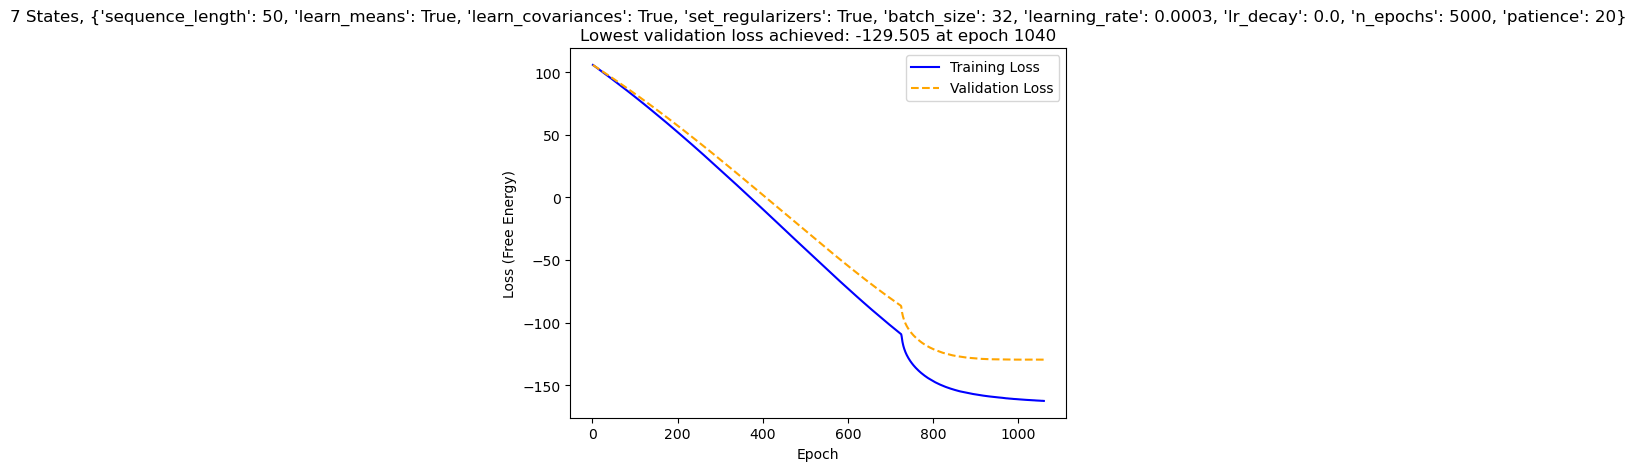

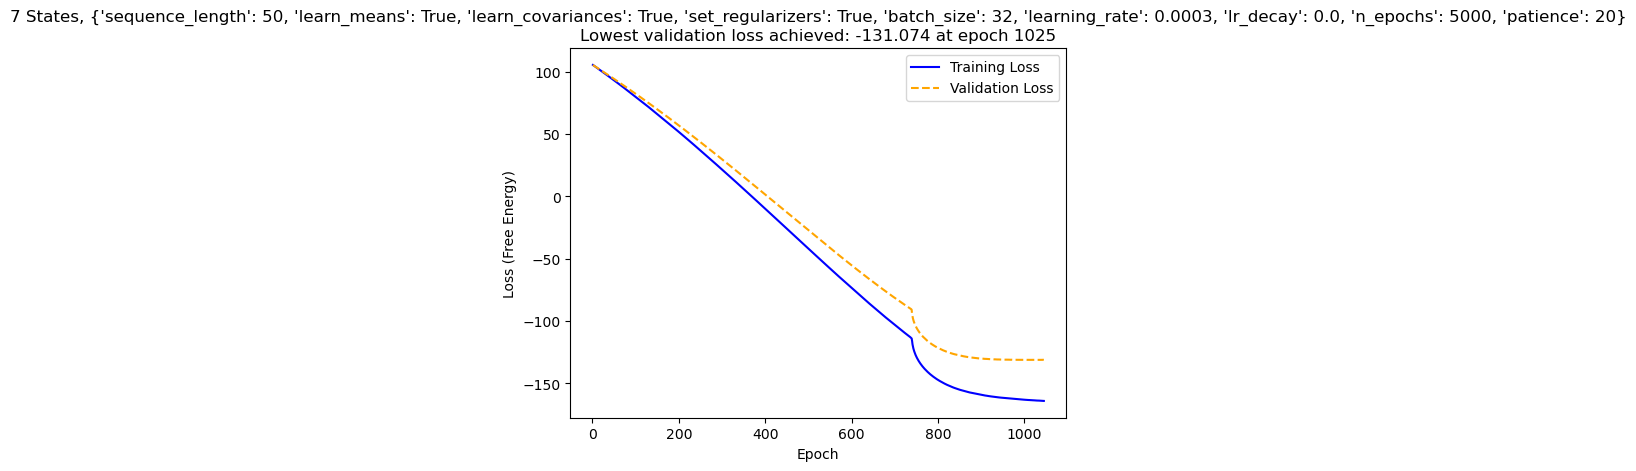

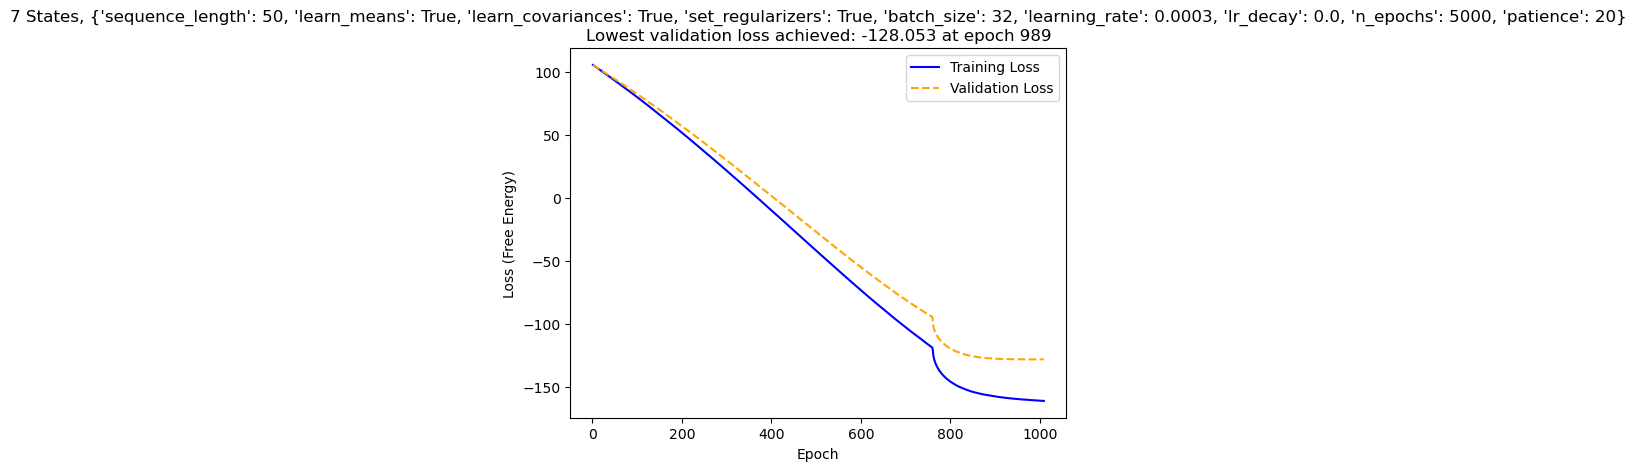

In [11]:
plot_cv_loss(grid_search_log, 7)

In [12]:
performance_df = hyperparam_performance(grid_search_log, 7)
performance_df

,k,hyperparams,average_outer_free_energy,best_inner_training_epochs
0,7,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003, 'lr_decay': 0.0, 'n_epochs': 5000, 'patience': 20}",-131.892399,"[1040, 1025, 989]"
1,7,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_decay': 0.005, 'n_epochs': 5000, 'patience': 20}",-131.850281,"[1952, 1946, 1946]"
2,7,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_decay': 0.0, 'n_epochs': 5000, 'patience': 20}",-131.798547,"[308, 319, 308]"
3,7,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003, 'lr_decay': 0.005, 'n_epochs': 5000, 'patience': 20}",-130.787360,"[2401, 2425, 2397]"


# Compute Model Evaluation Metrics on Full Dataset 

In [13]:
results_path = f'{experiment}/results/{hmm_run}'
model_eval_log = {}
model_eval_log_save_path = results_path + f'/model_eval_log_{hmm_run}.pkl'

if os.path.exists(model_eval_log_save_path):
    with open(model_eval_log_save_path, 'rb') as f:
        model_eval_log = pickle.load(f)
else:
    os.makedirs(results_path, exist_ok=True)

sorted(model_eval_log.keys())

[7]

In [14]:
run_full_model_eval(
    model_eval_log=model_eval_log, 
    model_eval_log_save_path=model_eval_log_save_path, 
    grid_search_log=grid_search_log,
    k_values=[7], 
    n_realizations=10, 
    model_save_metric='free_energy', # use free_energy to stay consistent with run_grid_search()
    seed=42, 
    full_data=full_data,
    results_path=results_path, 
)


Fitting full-data model with 7 states...
The model with 7 states has already been evaluated, skipping...


# Compute Summary Statistics

## Load model of interest and compute preliminary summary statistics

In [15]:
k_optimal = 7
best_realization_idx = model_eval_log[k_optimal]['best_realization_idx']
model = load(model_eval_log[k_optimal]['best_realization_path'])

2026-05-19 17:58:15 INFO osl-dynamics [mod_base.py:781:load]: Loading model: RLstim/results/LEiDA_116c_no_TDE/7_states/7_states_model


In [16]:
inf_params_path = f'{results_path}/{k_optimal}_states/inf_params'
os.makedirs(inf_params_path, exist_ok=True)

In [17]:
alpha_path = f'{inf_params_path}/alp_{k_optimal}_states.pkl'
if os.path.exists(alpha_path):
    alpha = pickle.load(open(alpha_path, 'rb'))
else:
    alpha = model.get_alpha(full_data)
    pickle.dump(alpha, open(alpha_path, 'wb'))

In [18]:
type(alpha), len(alpha) # each element of alpha is a subject

(list, 113)

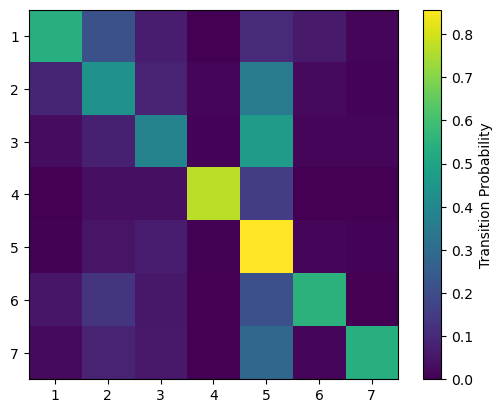

In [19]:
trans_matrix = model_eval_log[k_optimal]['realizations'][best_realization_idx]['trans_matrix']
plt.imshow(trans_matrix, origin='upper')
plt.xticks(ticks=range(0, k_optimal), labels=range(1, k_optimal + 1))
plt.yticks(ticks=range(0, k_optimal), labels=range(1, k_optimal + 1))
plt.colorbar(label='Transition Probability')
plt.show()

In [20]:
# Now the group-level means and covs
means, covs = model_eval_log[k_optimal]['realizations'][best_realization_idx]['means'], model_eval_log[k_optimal]['realizations'][best_realization_idx]['covs']
means.shape, covs.shape

((7, 116), (7, 116, 116))

In [21]:
# Hard classify the state probabilities (i.e., for each time point set each probability to either 0 or 1)
stc = np.array(modes.argmax_time_courses(alpha)) # state time course
print(stc.shape)

(113, 250, 7)


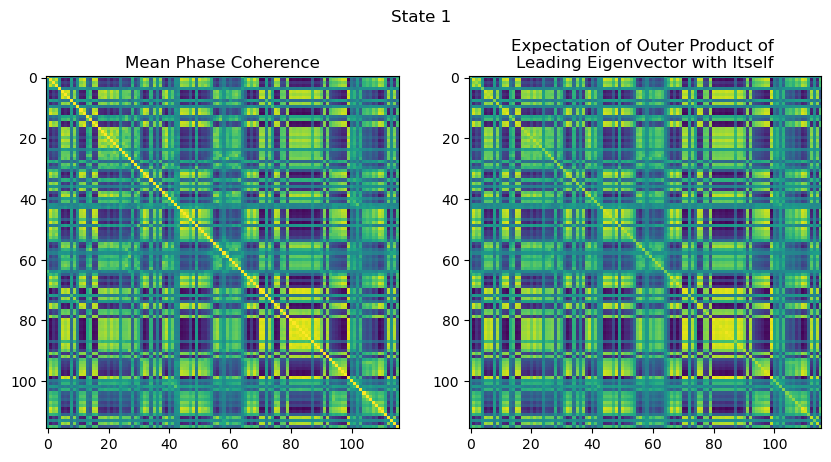

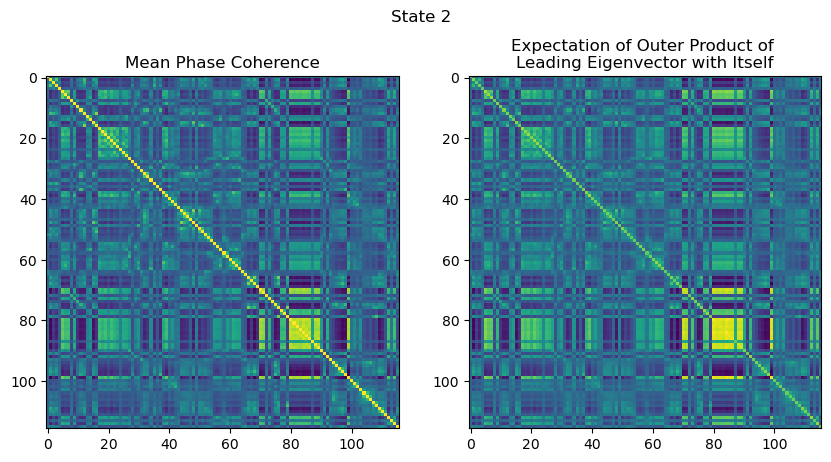

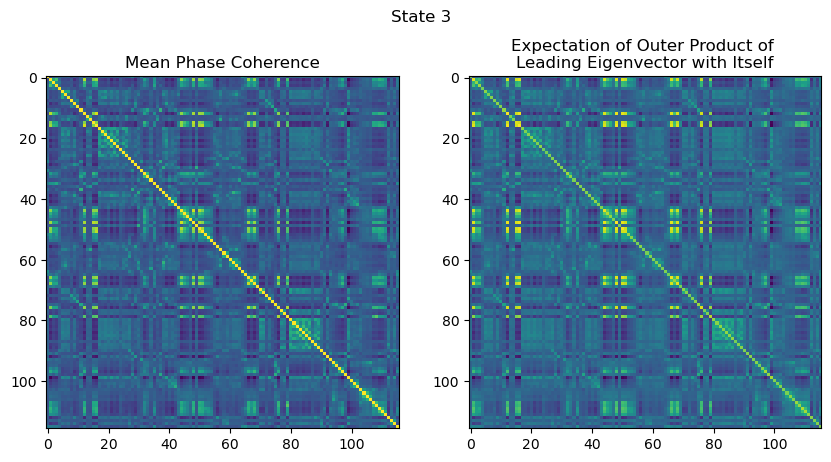

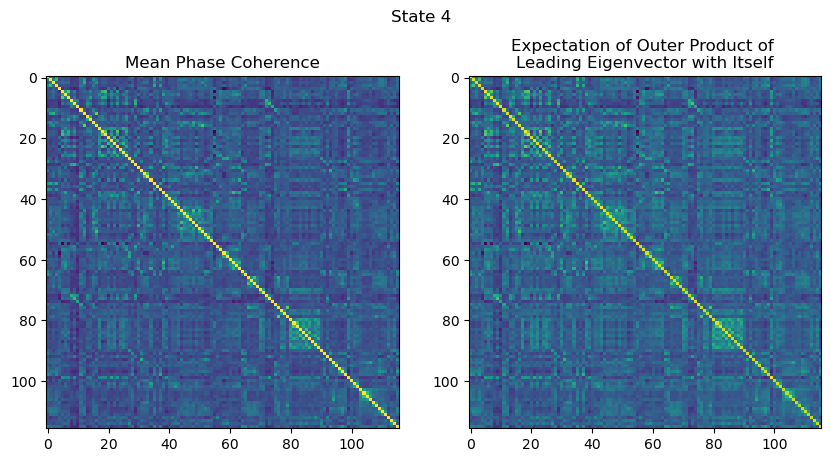

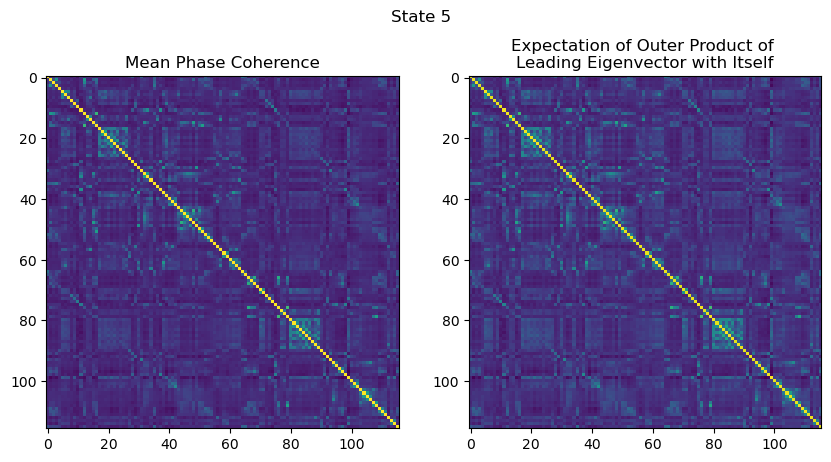

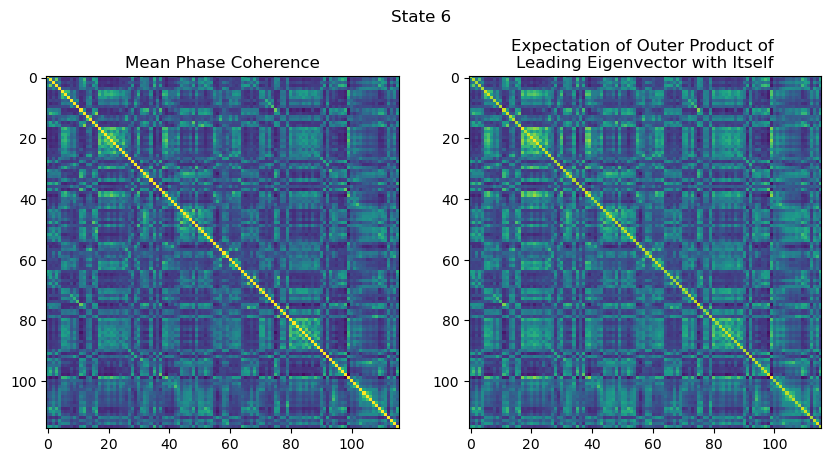

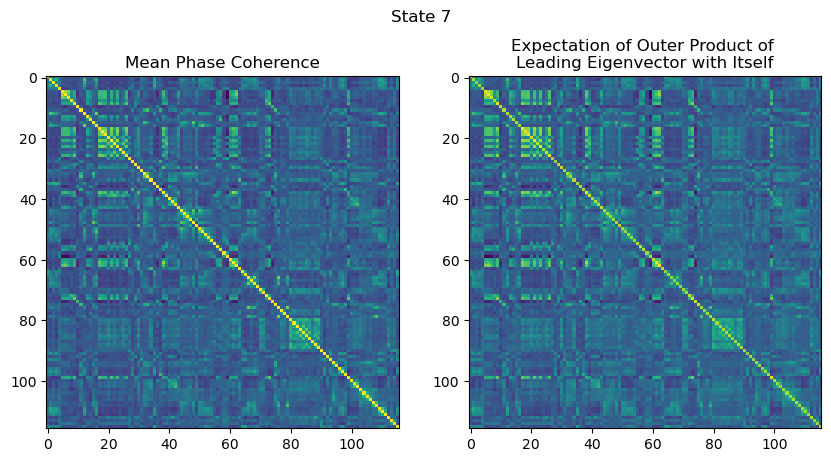

In [22]:
if data_prep_method == 'LEiDA':
    phase_coherence = np.load(data_path)
    mean_phase_coherences = get_mean_phase_coherences(
        phase_coherence=phase_coherence,
        full_data=full_data,
        stc=stc,
    )

    np.save(f'{results_path}/{k_optimal}_states/mean_phase_coherences.npy', mean_phase_coherences)
    
    outer_products = leida_sanity_check(
        mean_phase_coherences=mean_phase_coherences,
        state_means=means, 
        state_covs=covs,
        figsize=(10, 5),
    )

In [23]:
# Fractional occupancy (FO)
fo = modes.fractional_occupancies(stc)
fo.shape

(113, 7)

In [24]:
# FO of each state averaged across subjects
sorted_fos = [] # (state_num, FO)
mean_fos = np.mean(fo, axis=0)
for i in range(k_optimal):
    sorted_fos.append((i + 1, mean_fos[i]))

sorted_fos.sort(key=lambda x: x[1], reverse=True)
sorted_fos_df = pd.DataFrame({
    'state': [state for state, fo in sorted_fos],
    'fo': [fo for state, fo in sorted_fos]
})

sorted_fos_df

,state,fo
0,5,0.659257
1,3,0.100496
2,2,0.095504
3,1,0.043257
4,4,0.042973
5,6,0.035221
6,7,0.023292


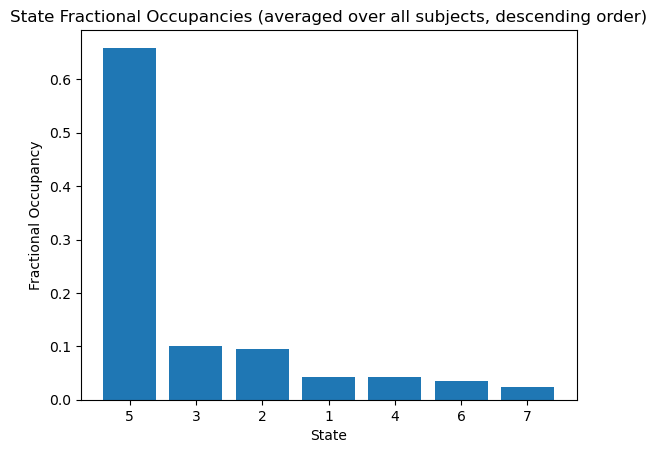

In [25]:
plt.bar(x=[str(x[0]) for x in sorted_fos], height=[x[1] for x in sorted_fos])
plt.title("State Fractional Occupancies (averaged over all subjects, descending order)")
plt.xlabel("State")
plt.ylabel("Fractional Occupancy")
plt.show()

In [26]:
assignment_df = pd.DataFrame({
    'state': [state for state, fo in sorted_fos],
    'total_n_samples_assigned': [np.sum(stc[:, :, state - 1] == 1) for state, fo in sorted_fos]
})

assignment_df

,state,total_n_samples_assigned
0,5,18624
1,3,2839
2,2,2698
3,1,1222
4,4,1214
5,6,995
6,7,658


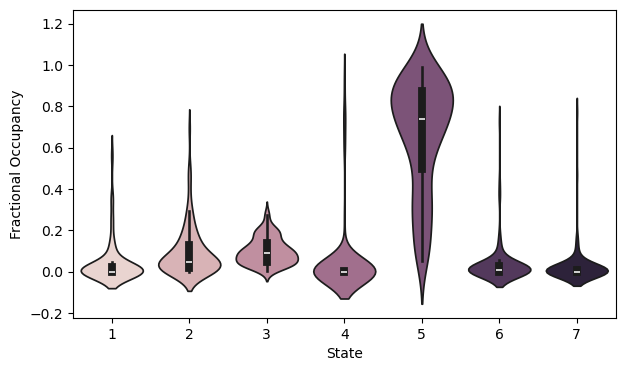

In [27]:
# Plot the distribution of fractional occupancy (FO) across subjects
fig, ax = plotting.plot_violin(fo.T, x_label="State", y_label="Fractional Occupancy")

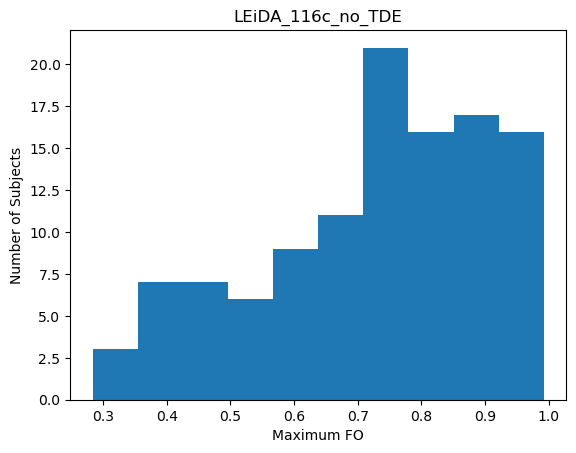

In [28]:
# Plot historgram of maximum FOs (maxFOs) to make sure there aren't states dominating subject time courses
fig, ax = plt.subplots(1, 1)
ax.hist(np.max(fo, axis=1))
ax.set_title(hmm_run)
ax.set_xlabel("Maximum FO")
ax.set_ylabel("Number of Subjects")

plt.show()

In [29]:
# Mean maximum fractional occupancy for each experimental group
mean_maxfo_df = pd.DataFrame({
    'group': np.unique(y),
    'mean_maxfo': [np.mean(np.max(fo[np.where(y == group)[0],], axis=1)) for group in np.unique(y)]
})

mean_maxfo_df

,group,mean_maxfo
0,CCI_CIMT_07d,0.677333
1,CCI_CIMT_21d,0.806400
2,CCI_CIMT_49d,0.728286
3,CCI_none_07d,0.666400
4,CCI_none_21d,0.779467
5,CCI_none_49d,0.722133
6,SHM_none_07d,0.647000
7,SHM_none_21d,0.815500
8,SHM_none_49d,0.684000


In [30]:
count = 0
for subj_idx in np.where(np.max(fo, axis=1) >= 0.9)[0]:
    count += 1
    print(subj_order[subj_idx][-17:])

count

CCI_CIMT_07d_004
CCI_CIMT_07d_020
CCI_CIMT_07d_022
CCI_CIMT_21d_020
CCI_CIMT_21d_022
CCI_CIMT_21d_024
CCI_CIMT_21d_040
CCI_CIMT_49d_039
CCI_none_07d_021
CCI_none_07d_023
CCI_none_21d_003
CCI_none_21d_019
CCI_none_21d_021
CCI_none_21d_031
CCI_none_21d_035
CCI_none_49d_003
CCI_none_49d_023
CCI_none_49d_025
CCI_none_49d_031
SHM_none_07d_014
SHM_none_07d_018
SHM_none_21d_028


22

## Subject-Level State Time Courses (Viterbi Paths)

In [65]:
if experiment == 'LLstim' or experiment == 'RLstim':
    stim_times = ([0] * 15 + [1] * 10) * 10
    print(len(stim_times))

250


### 07d

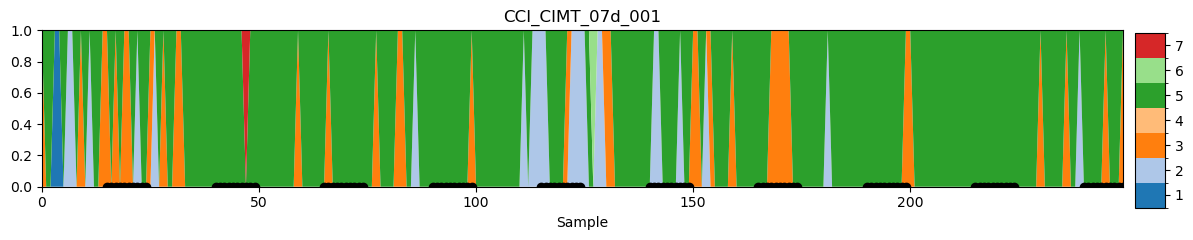

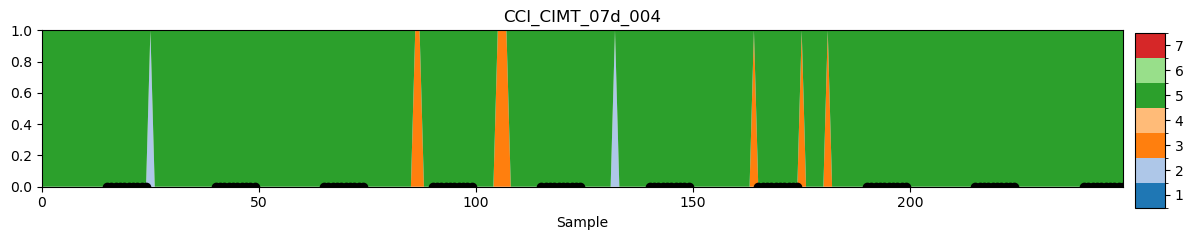

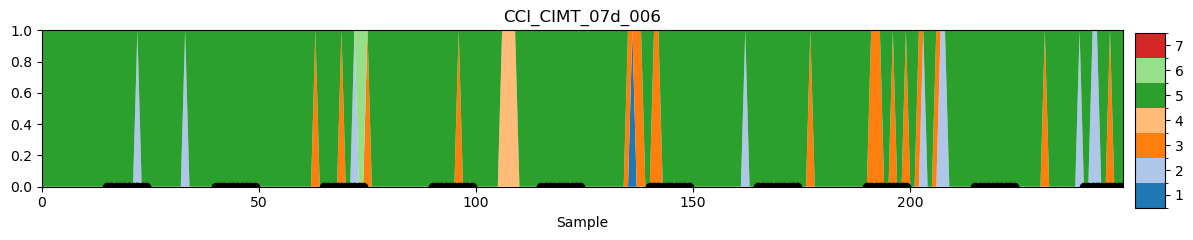

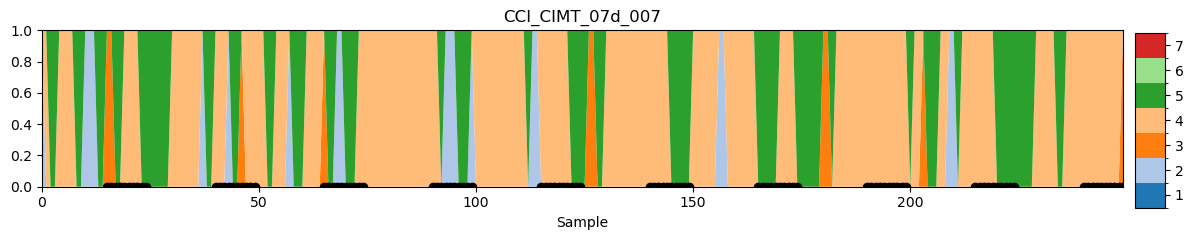

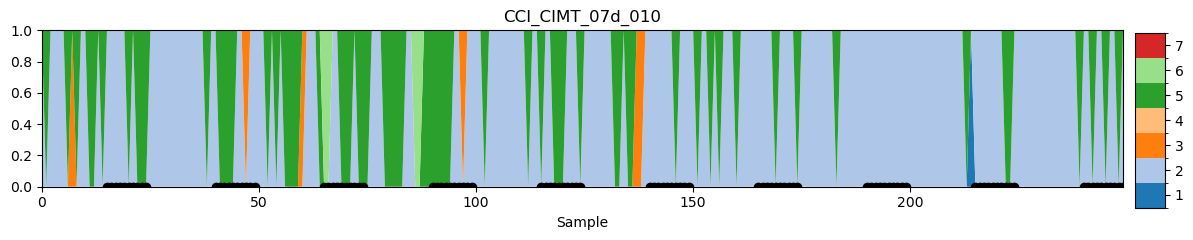

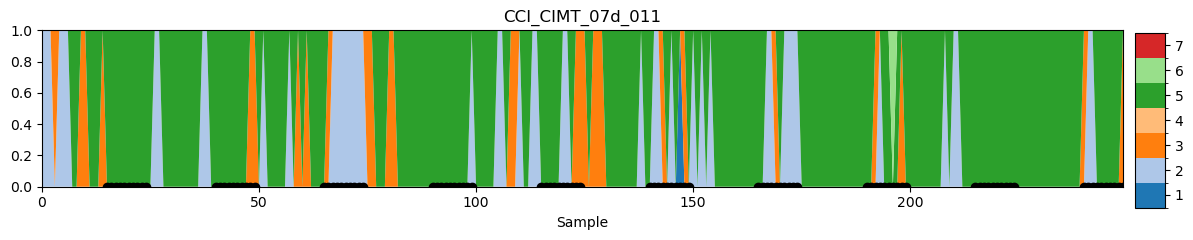

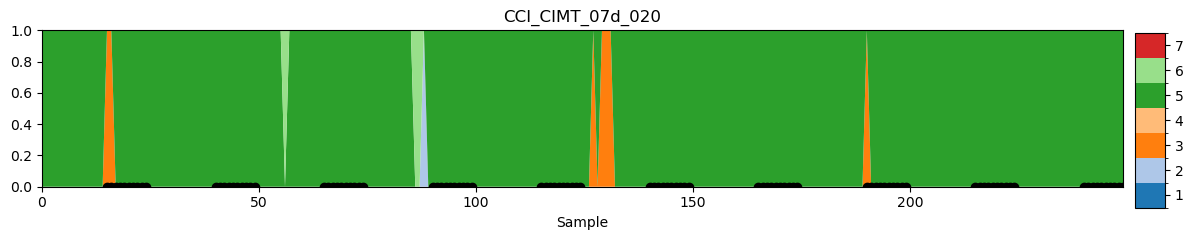

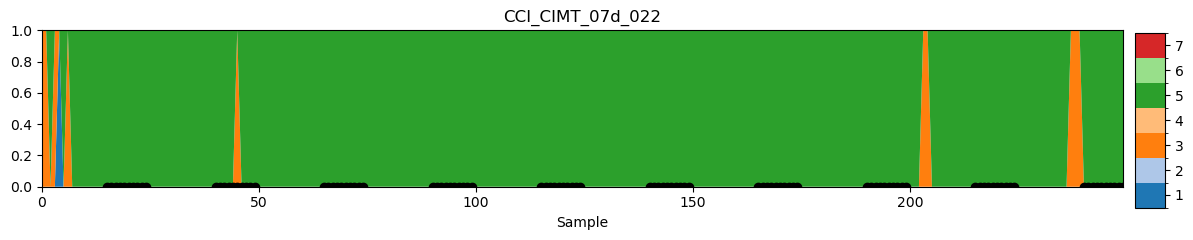

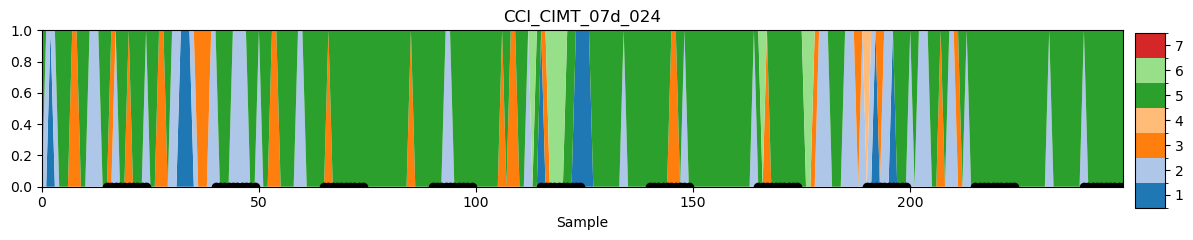

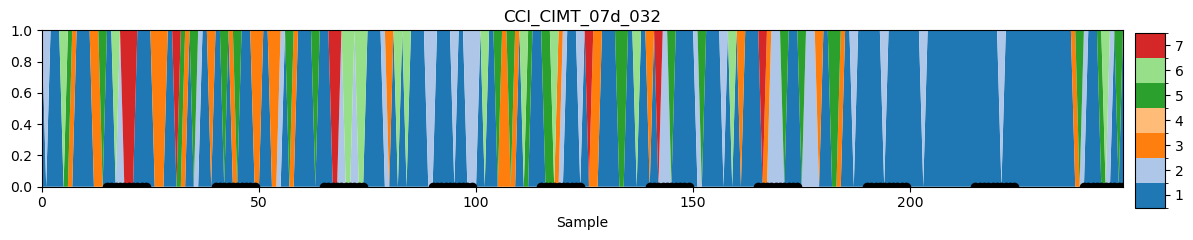

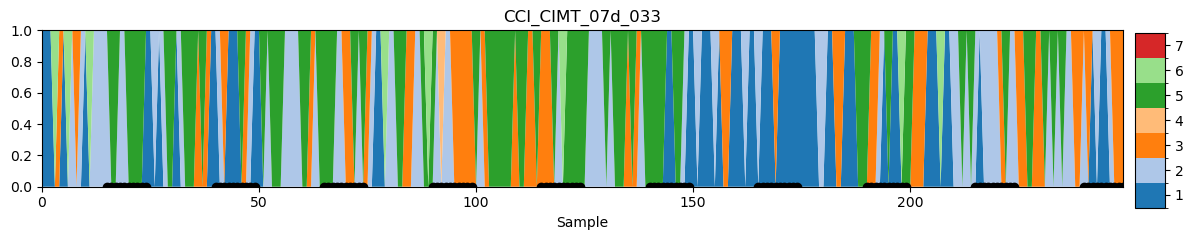

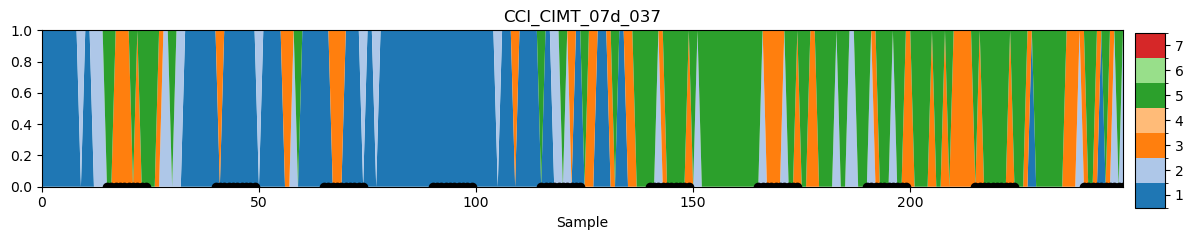

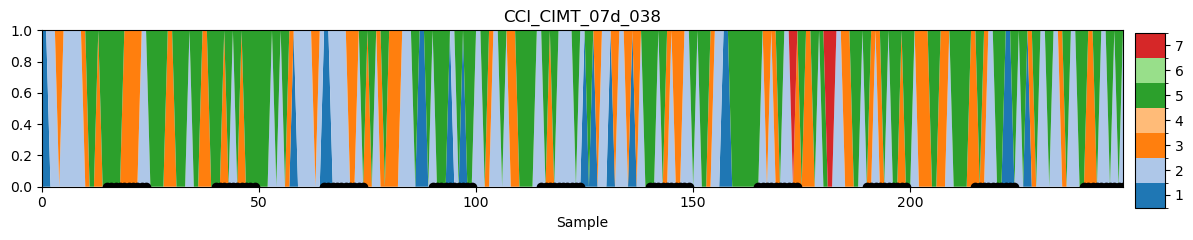

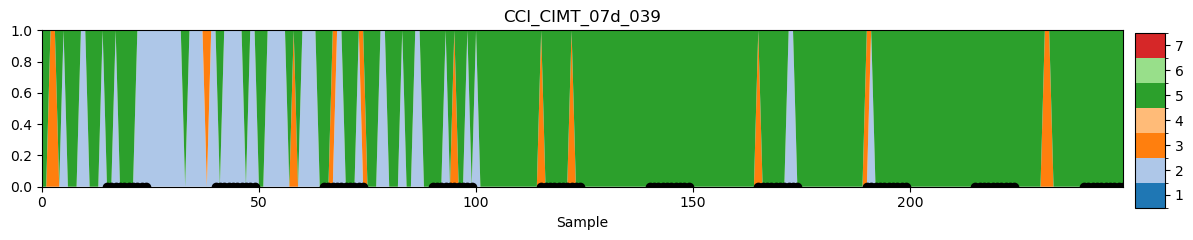

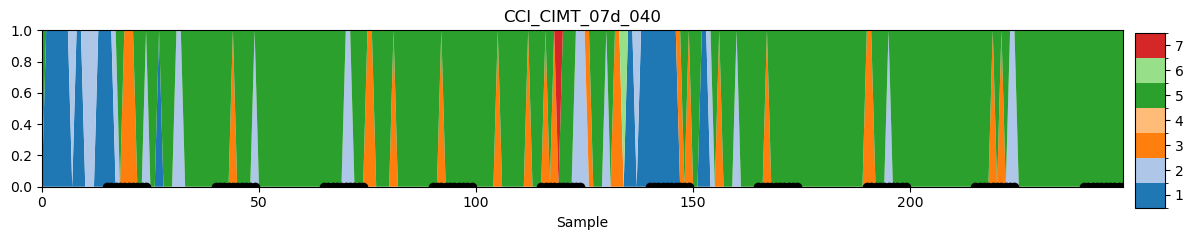

In [66]:
for subj in np.where(y == 'CCI_CIMT_07d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

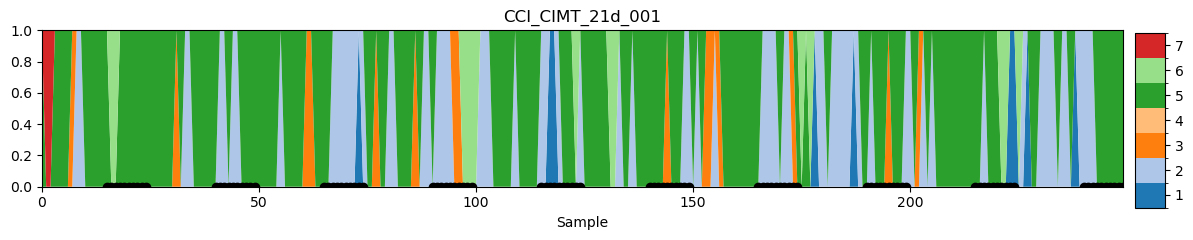

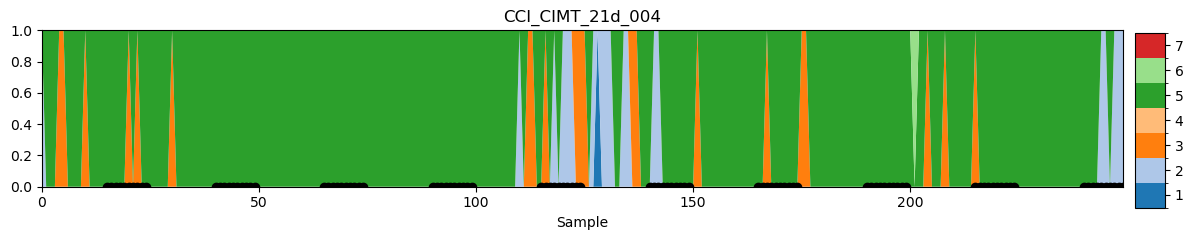

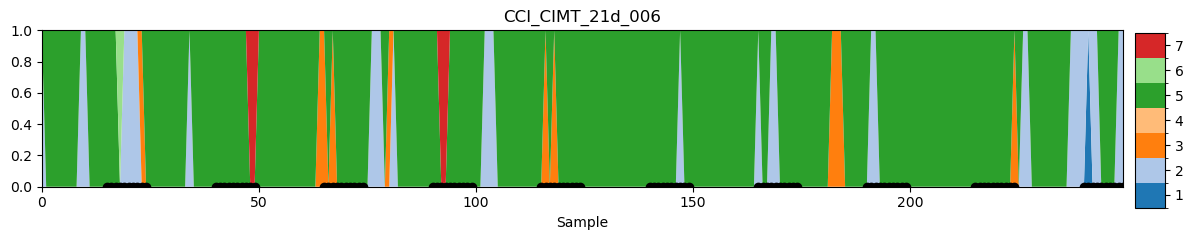

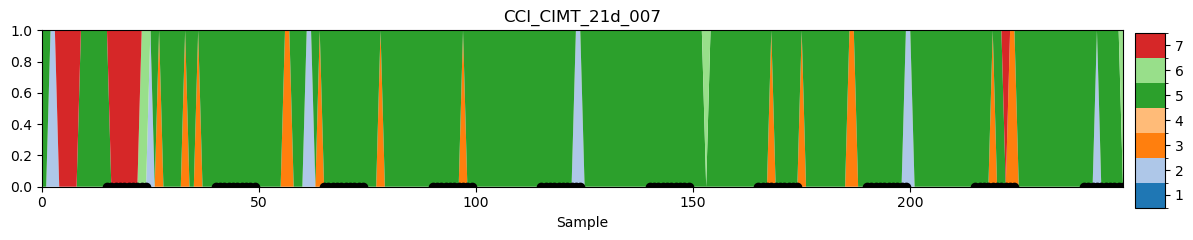

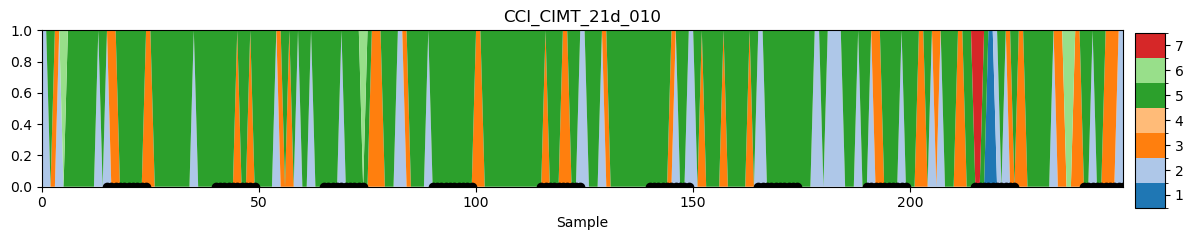

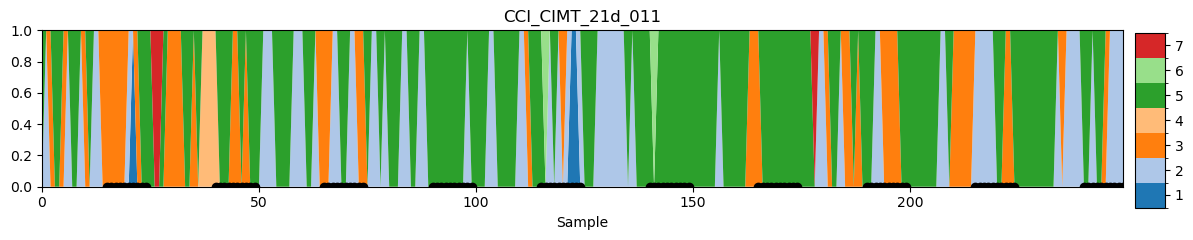

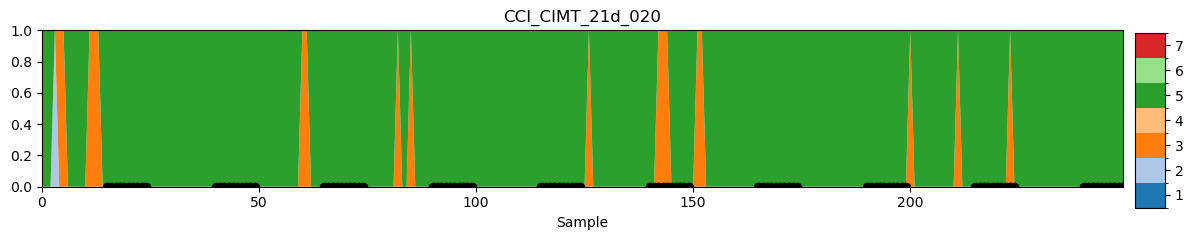

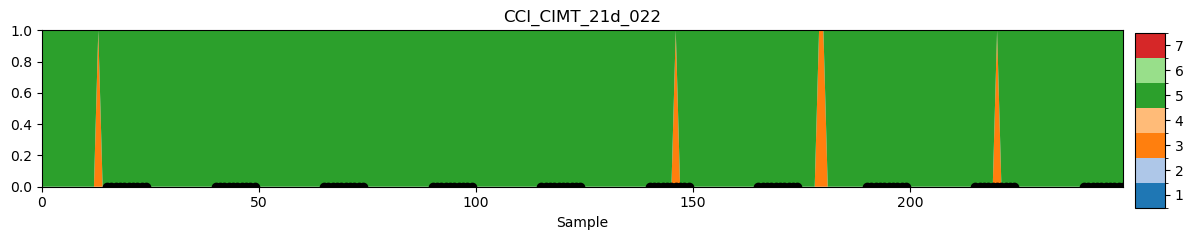

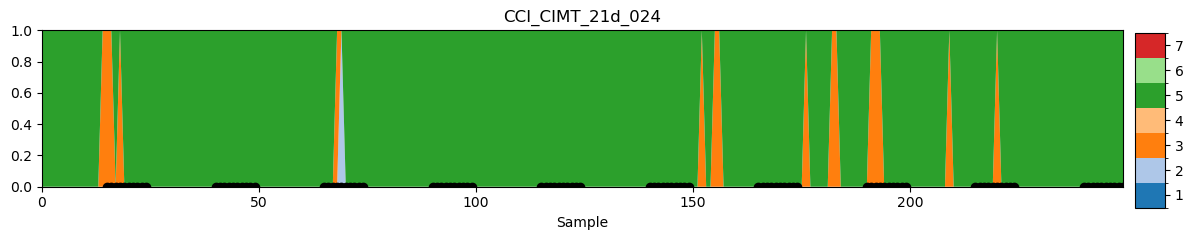

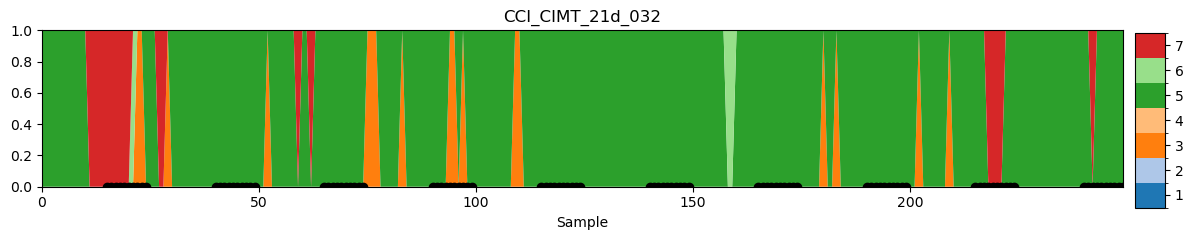

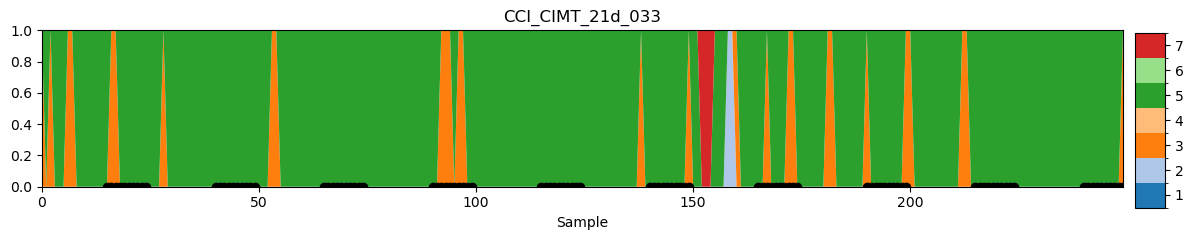

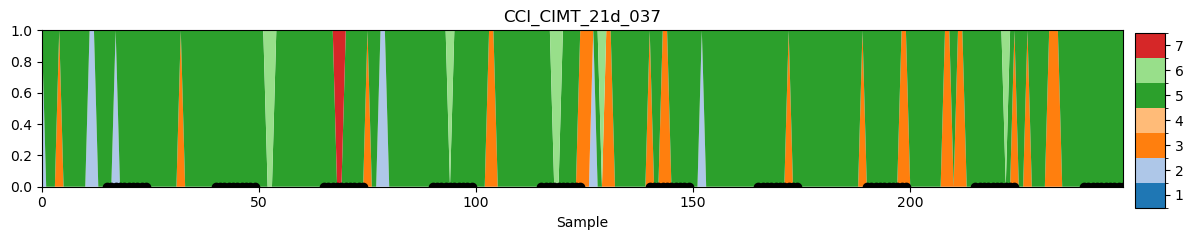

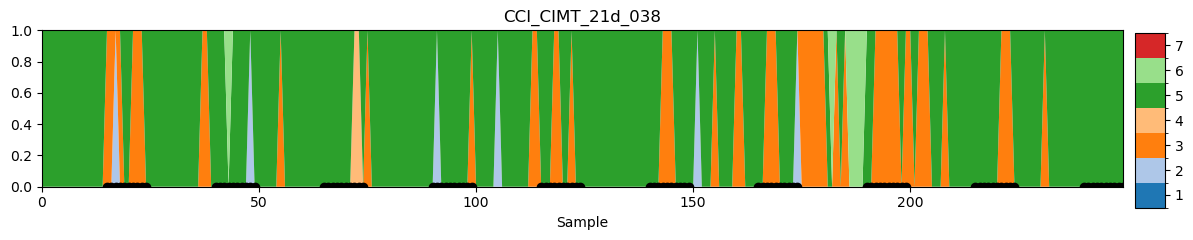

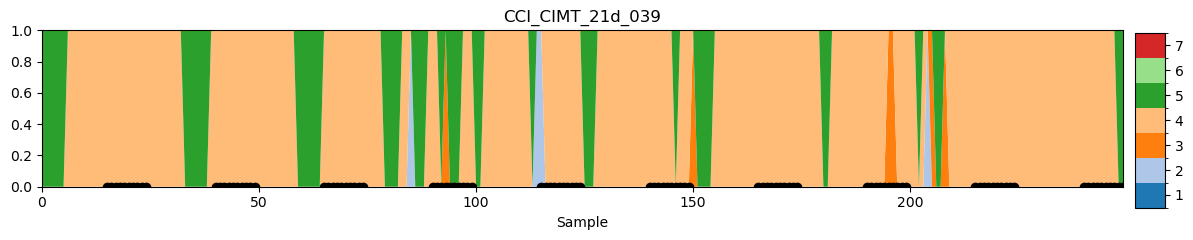

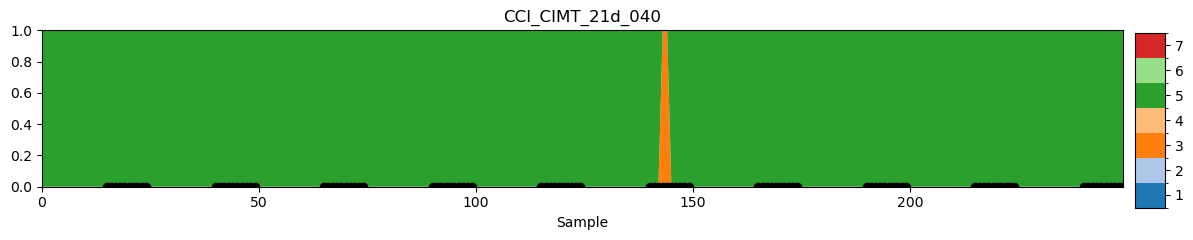

In [67]:
for subj in np.where(y == 'CCI_CIMT_21d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

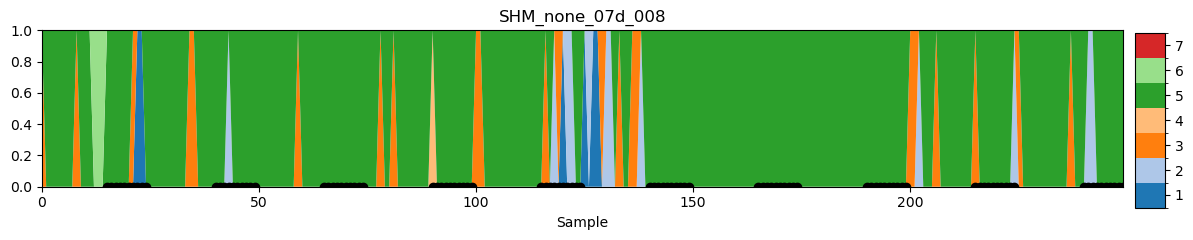

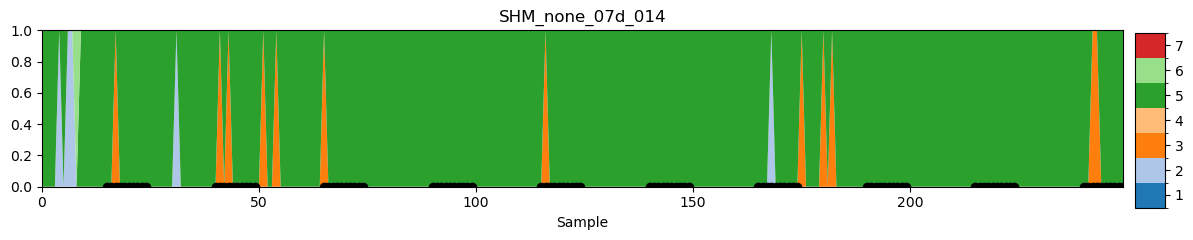

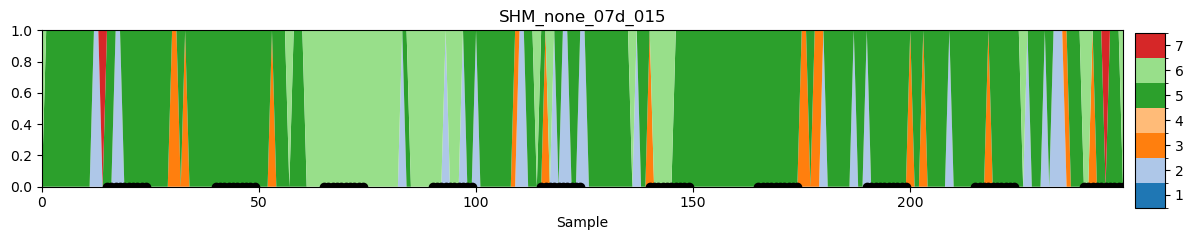

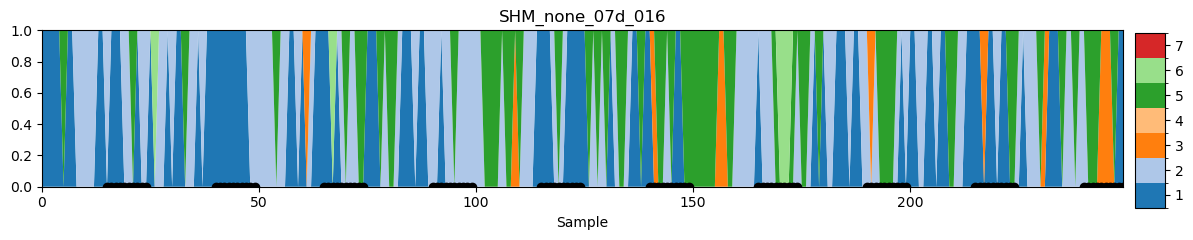

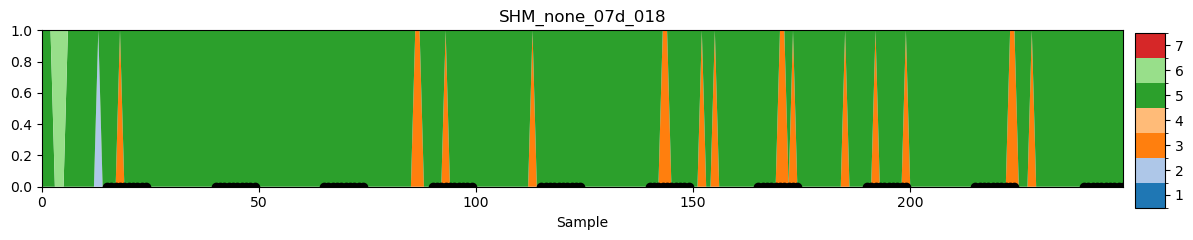

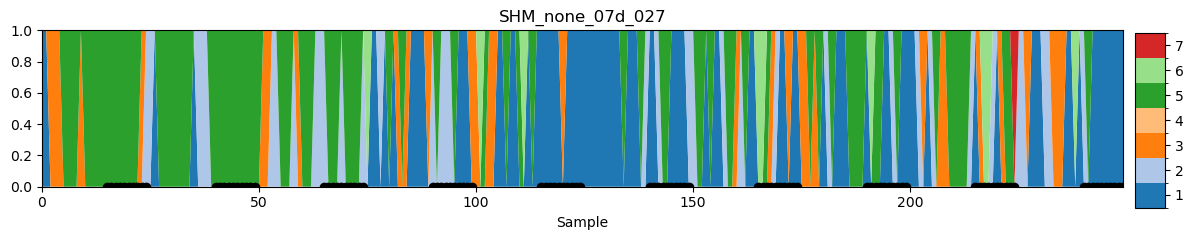

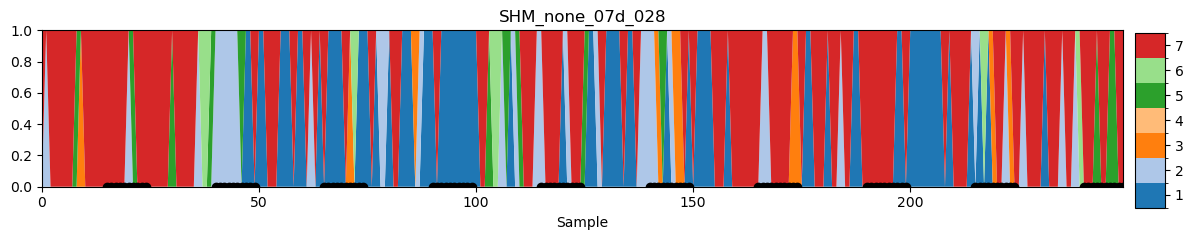

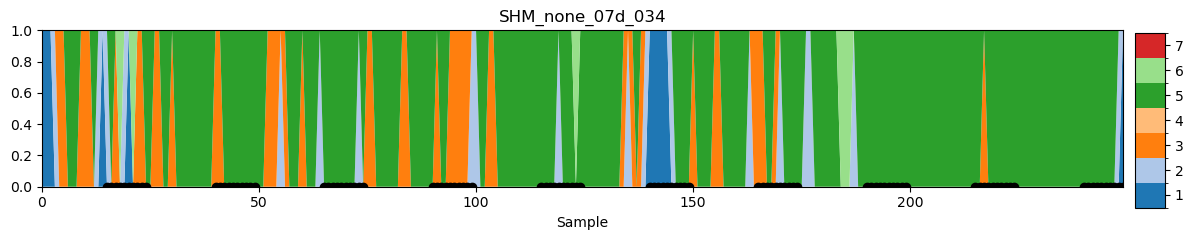

In [68]:
for subj in np.where(y == 'SHM_none_07d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

### 21d

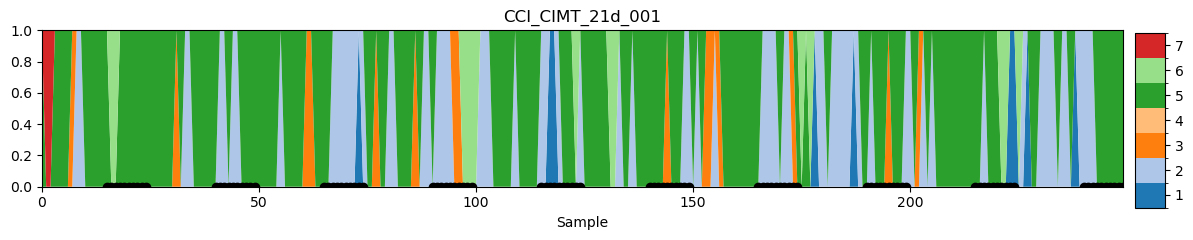

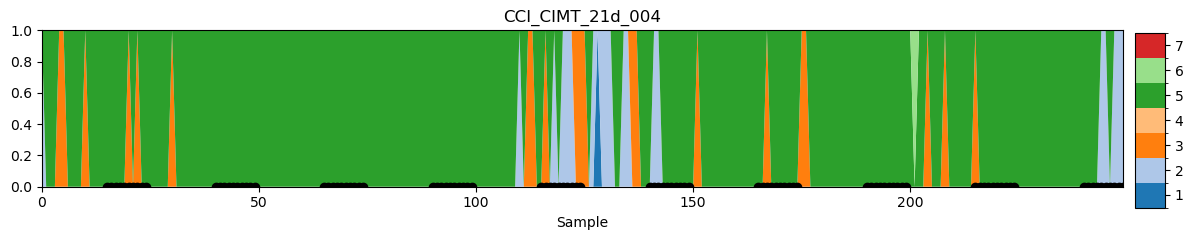

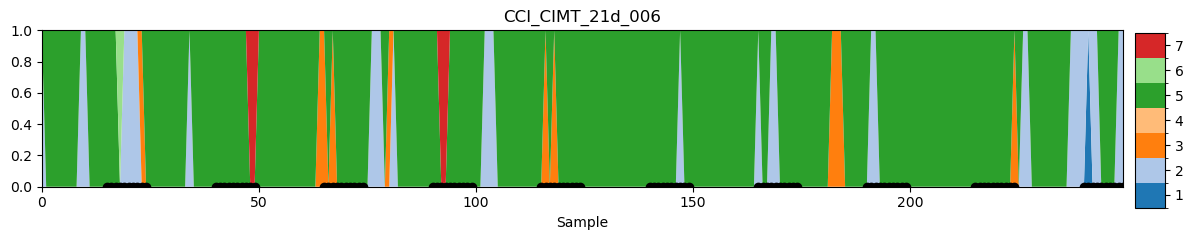

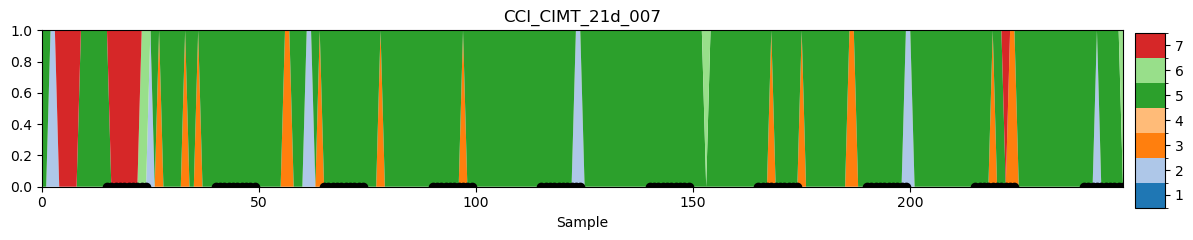

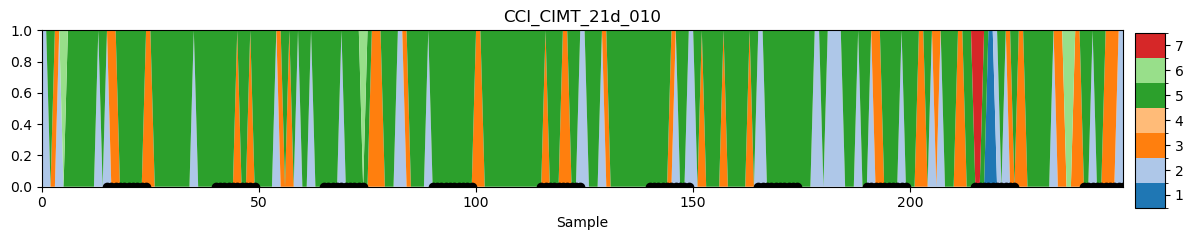

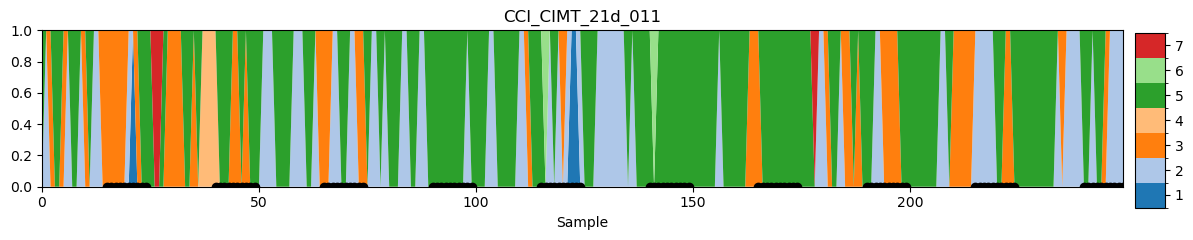

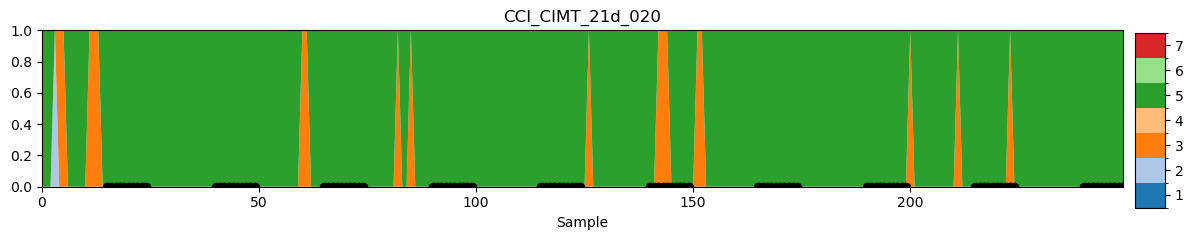

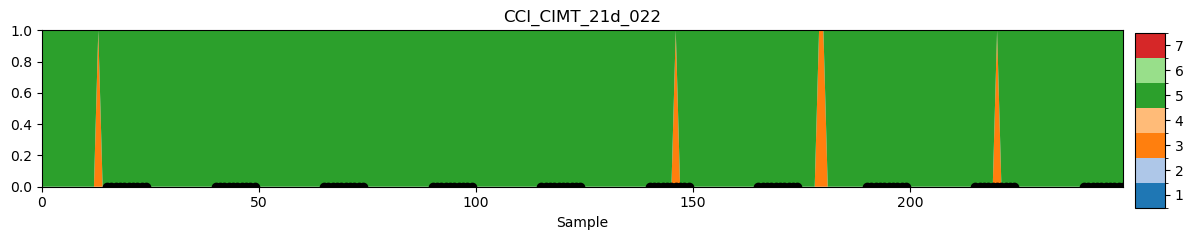

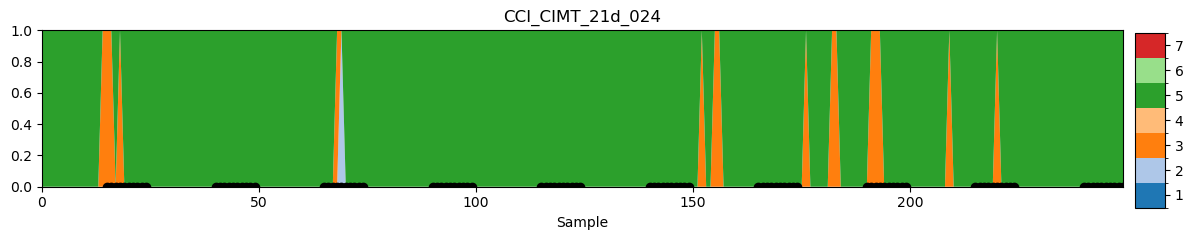

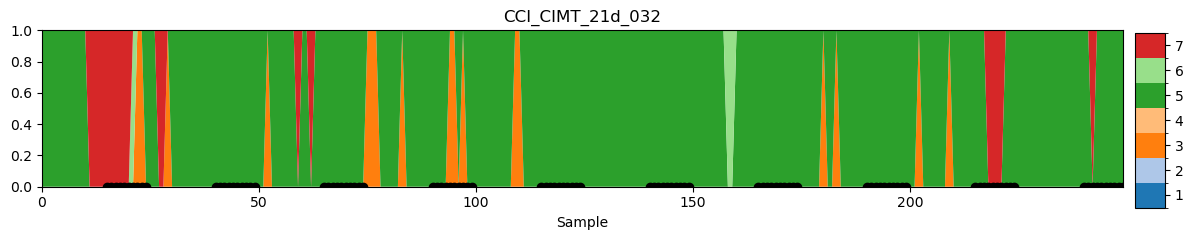

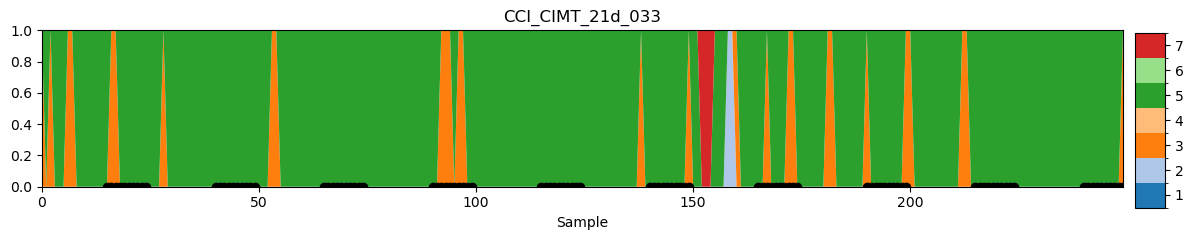

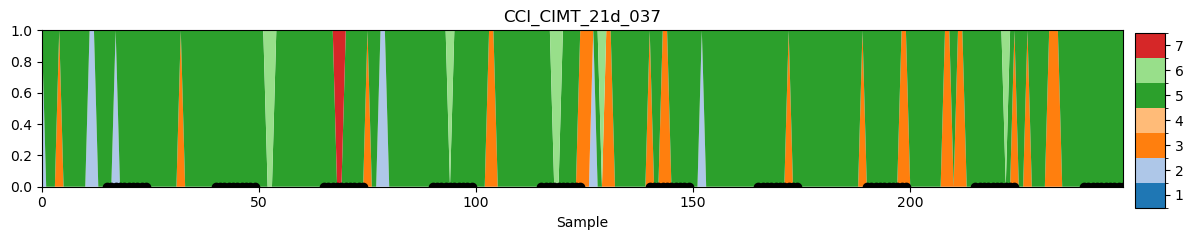

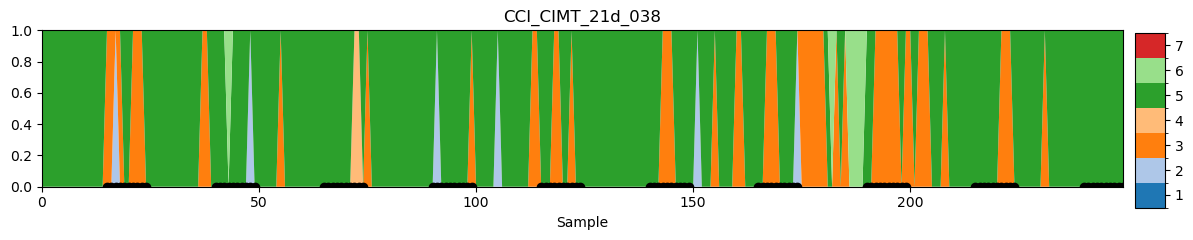

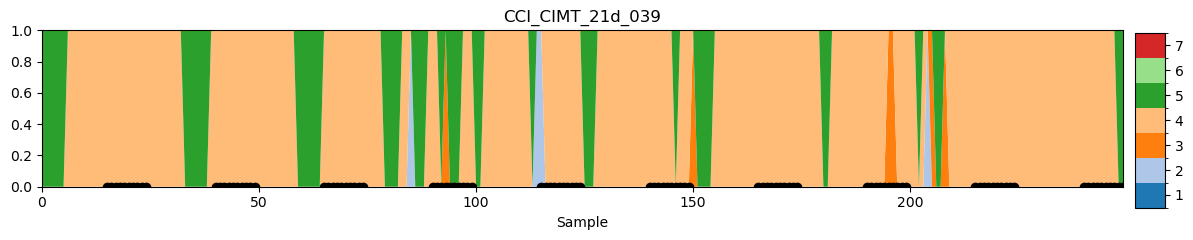

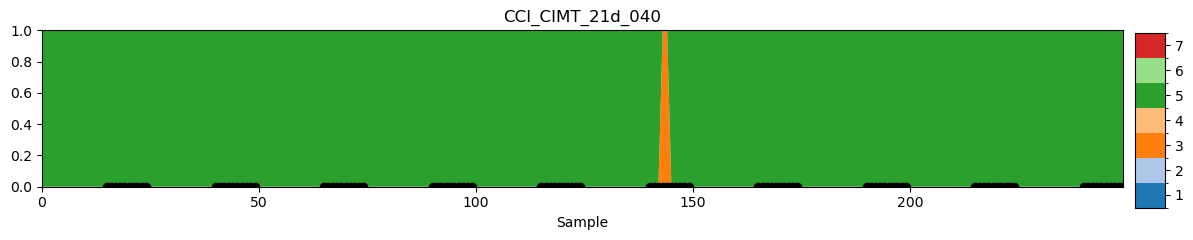

In [69]:
for subj in np.where(y == 'CCI_CIMT_21d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

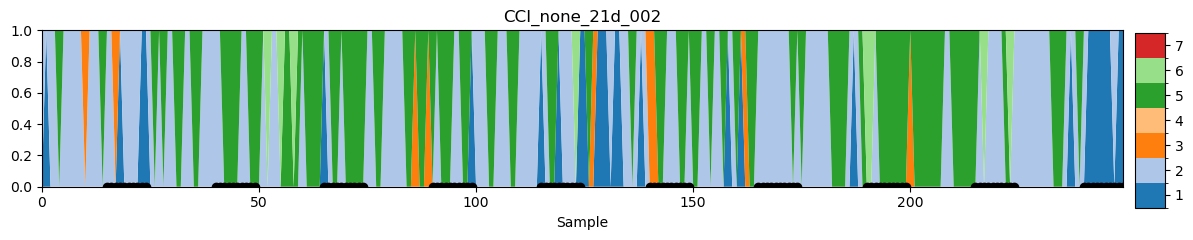

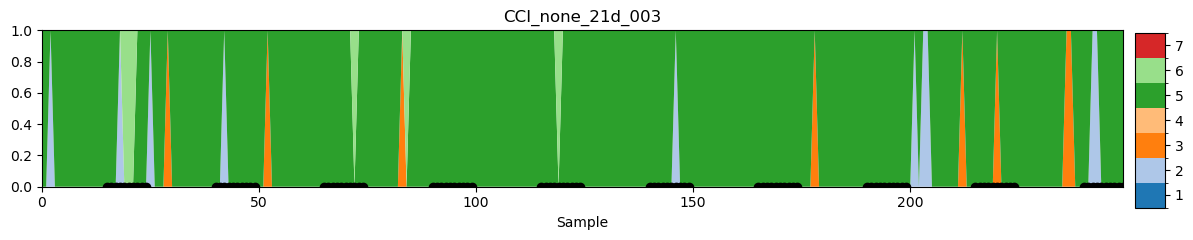

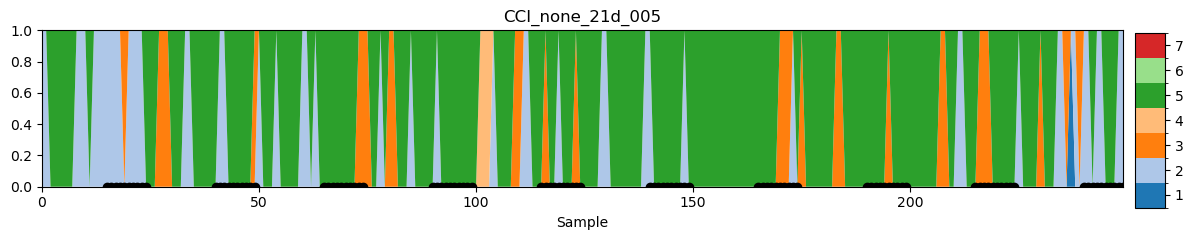

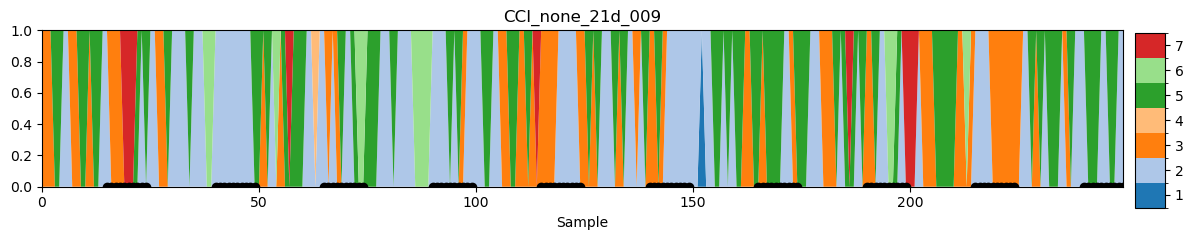

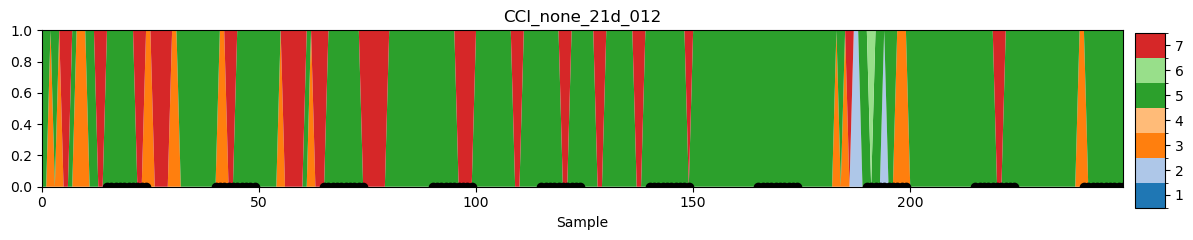

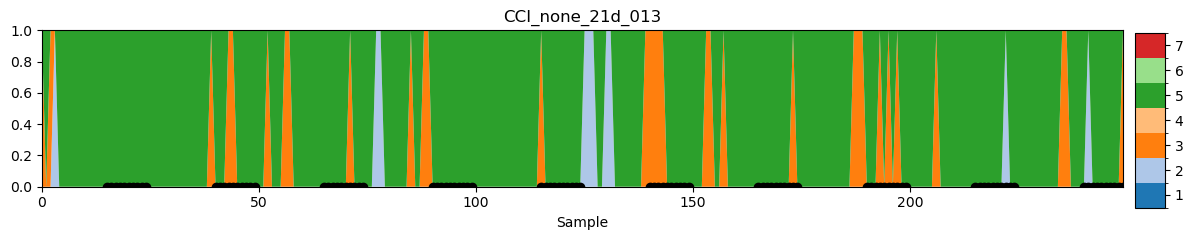

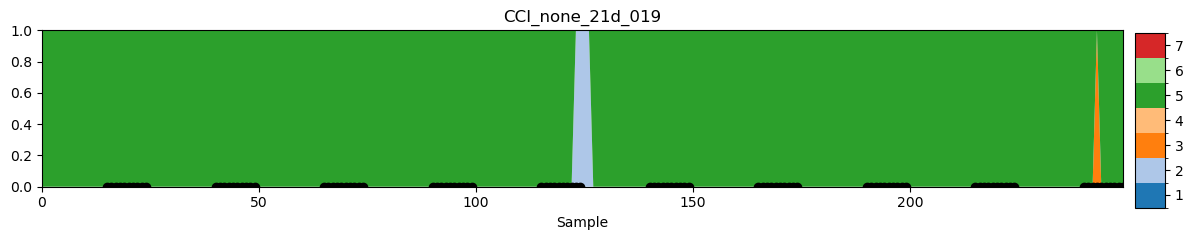

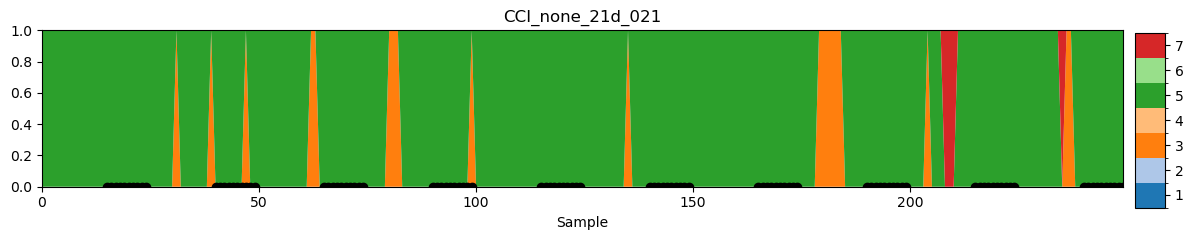

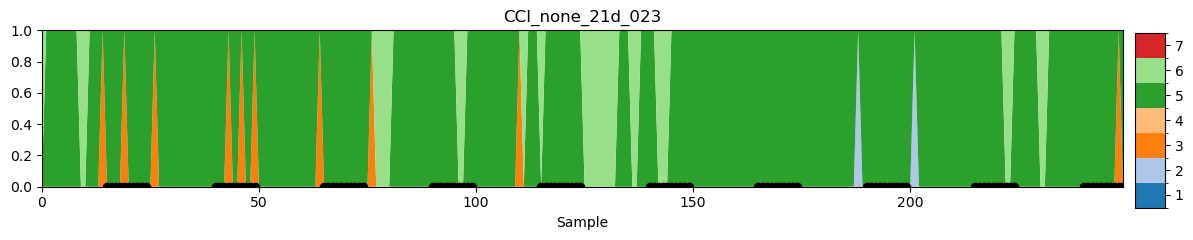

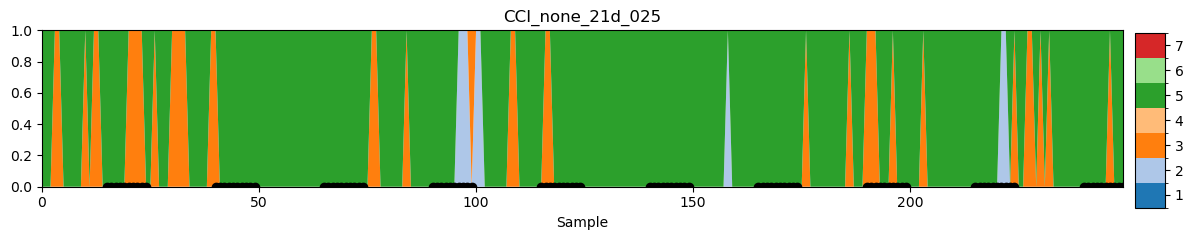

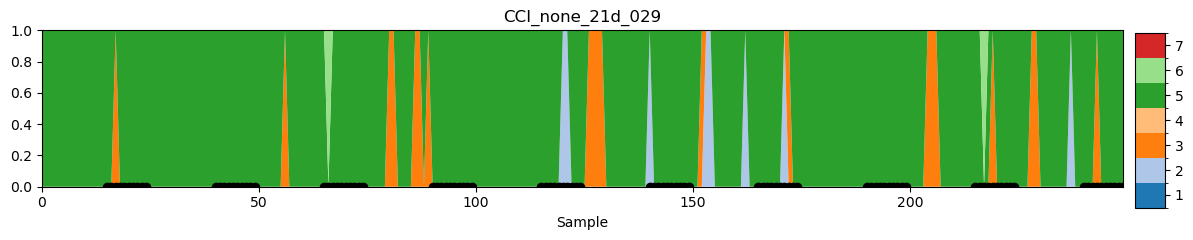

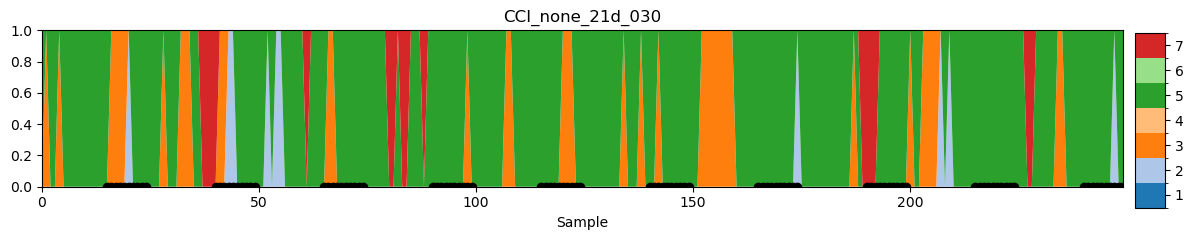

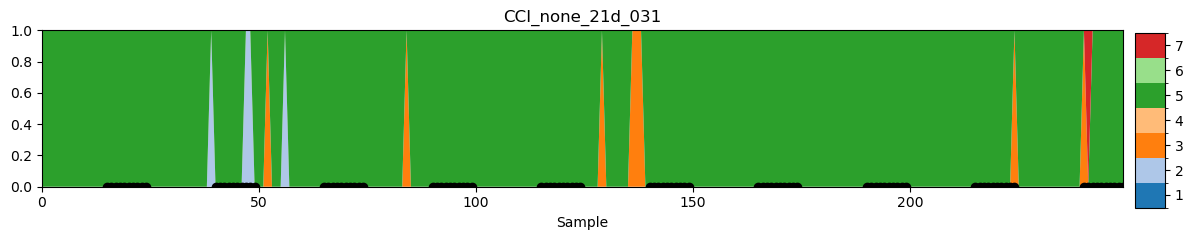

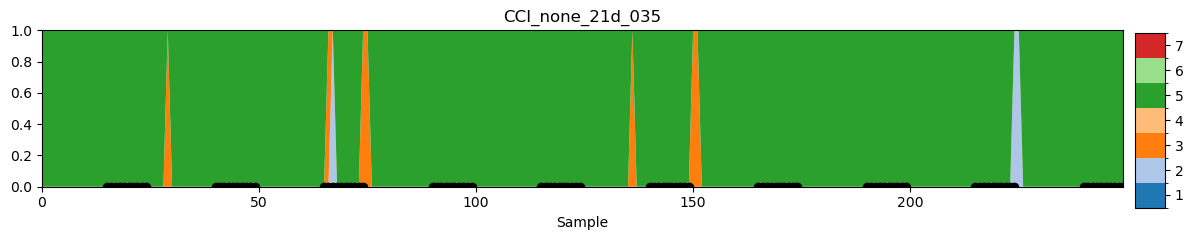

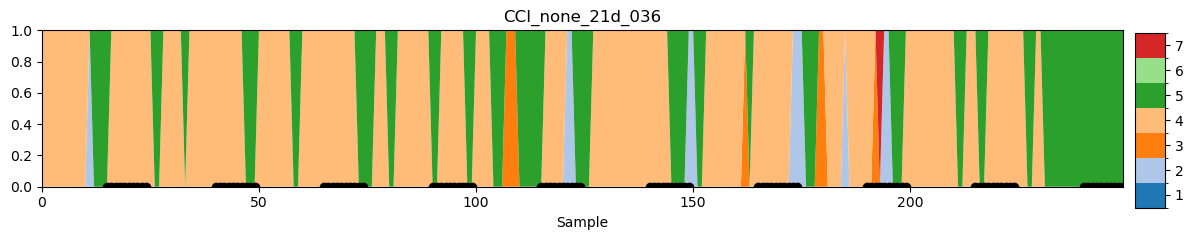

In [70]:
for subj in np.where(y == 'CCI_none_21d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

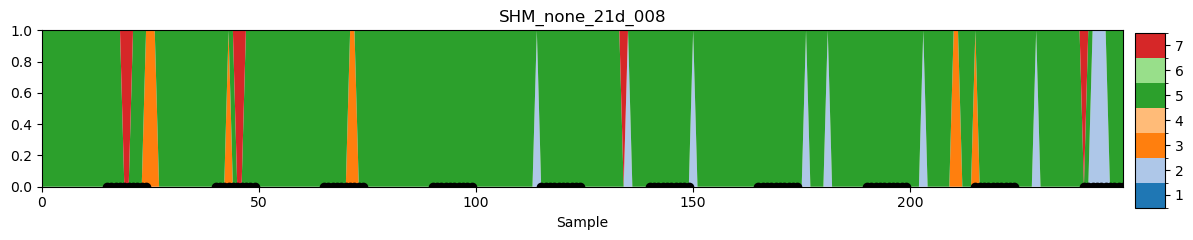

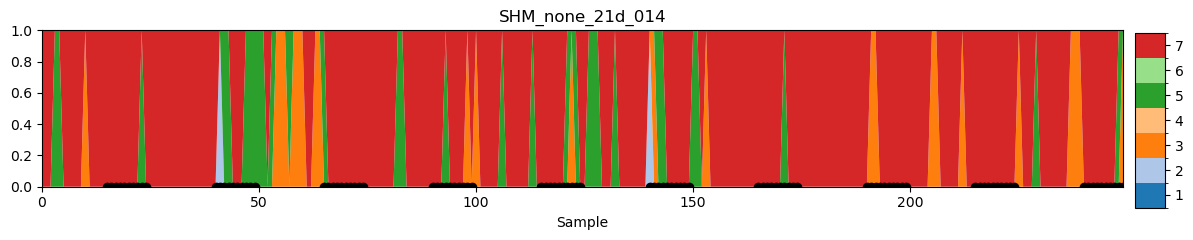

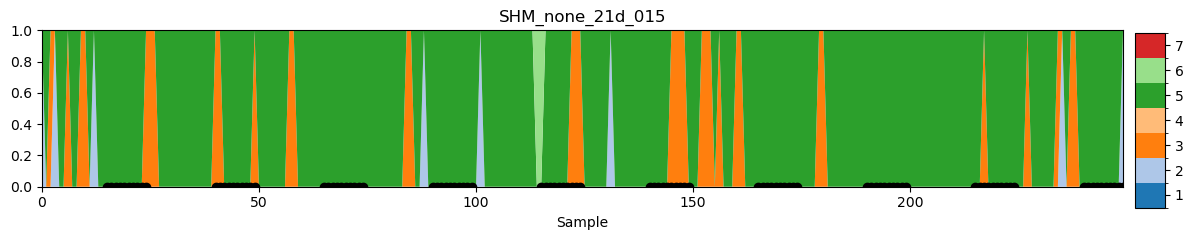

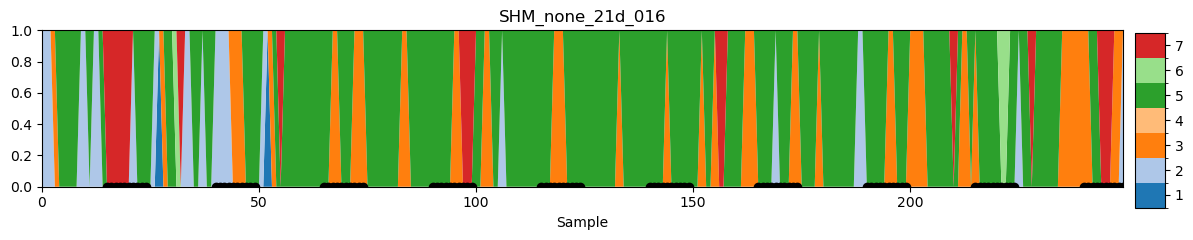

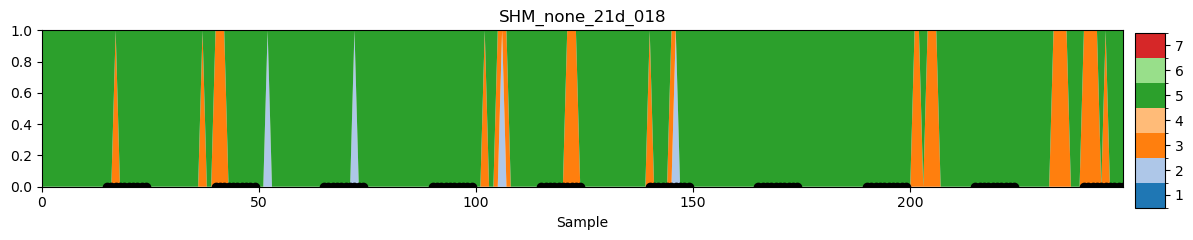

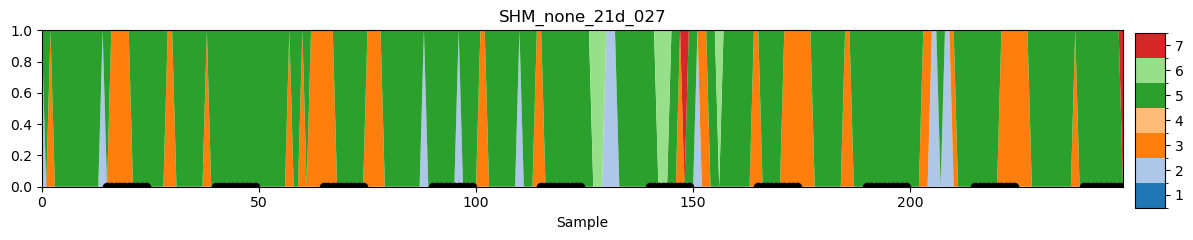

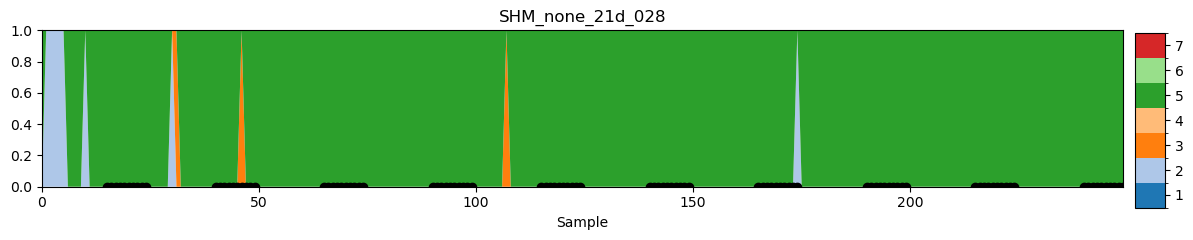

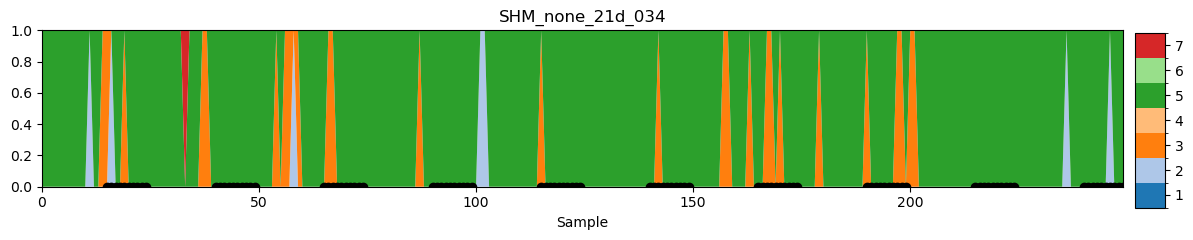

In [71]:
for subj in np.where(y == 'SHM_none_21d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

### 49d

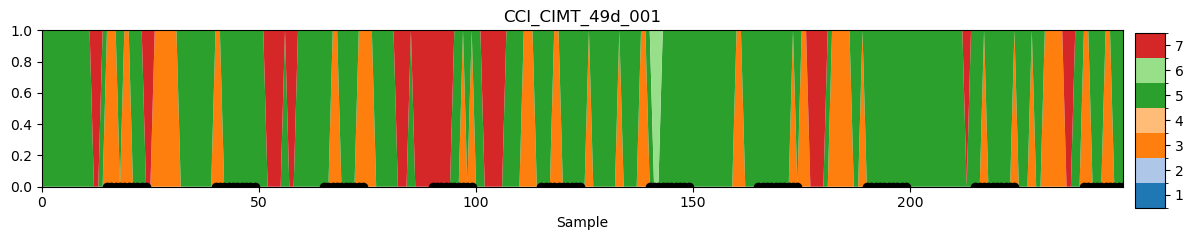

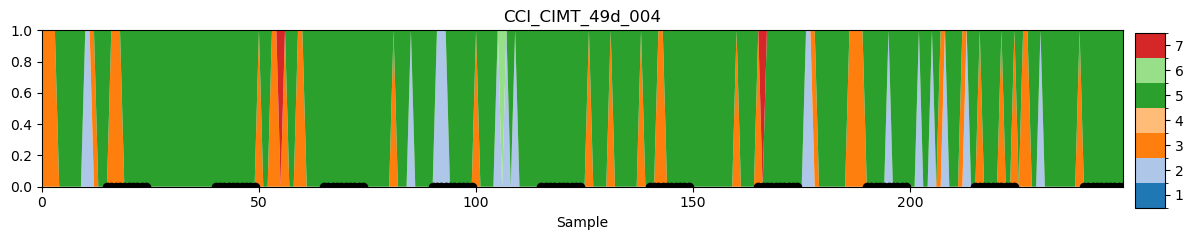

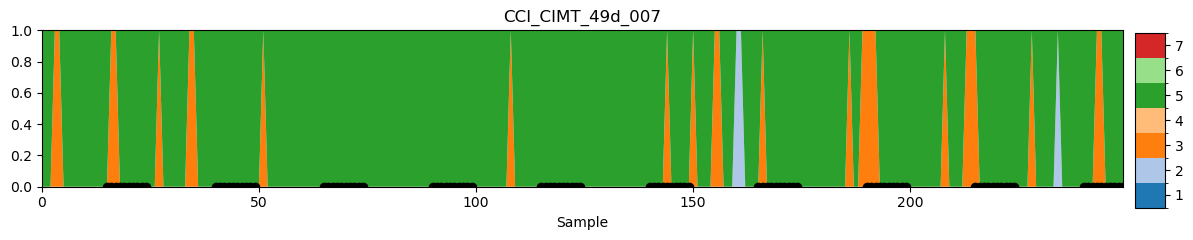

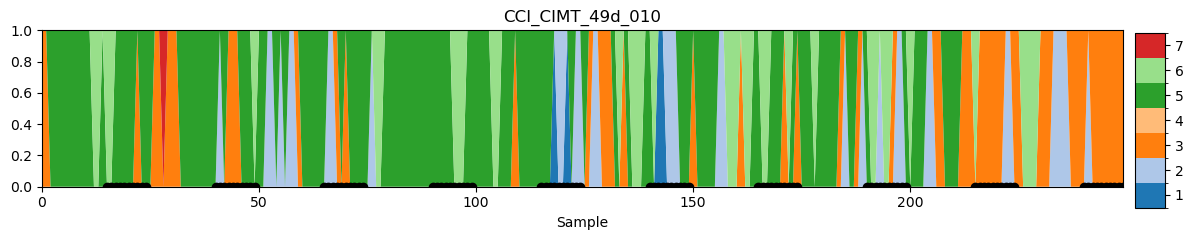

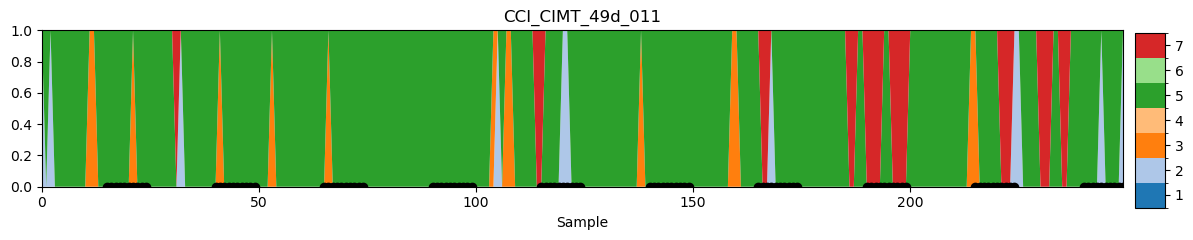

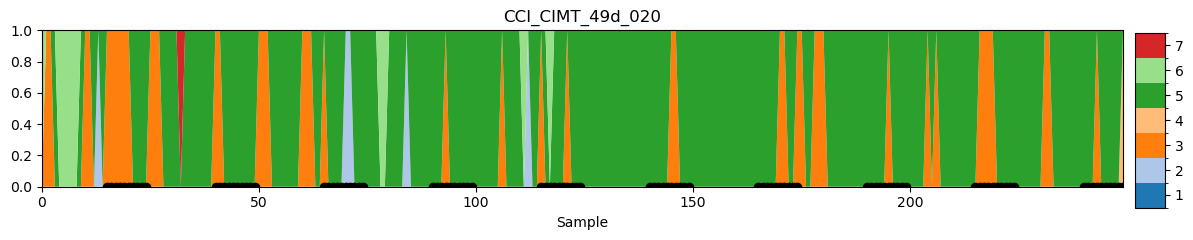

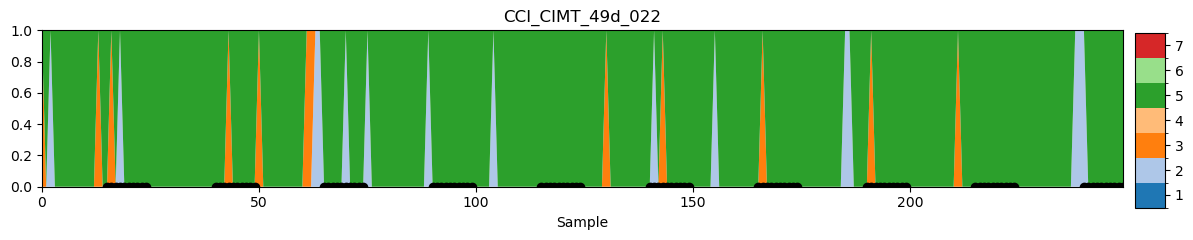

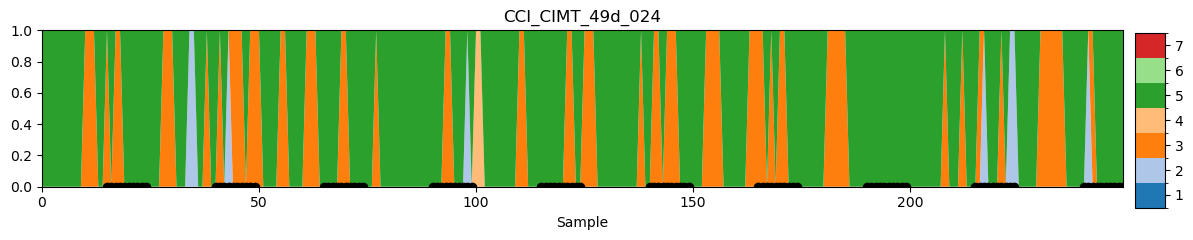

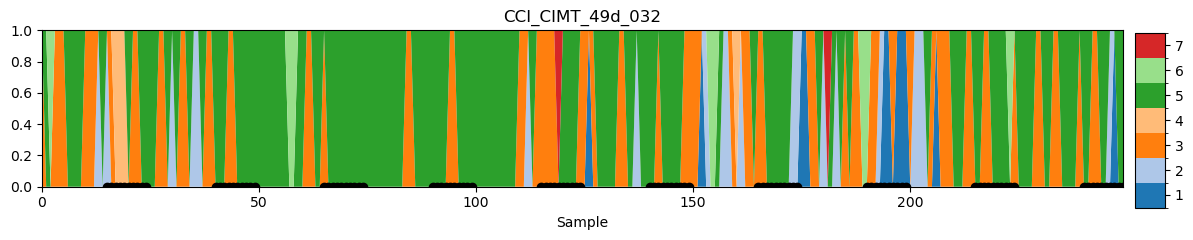

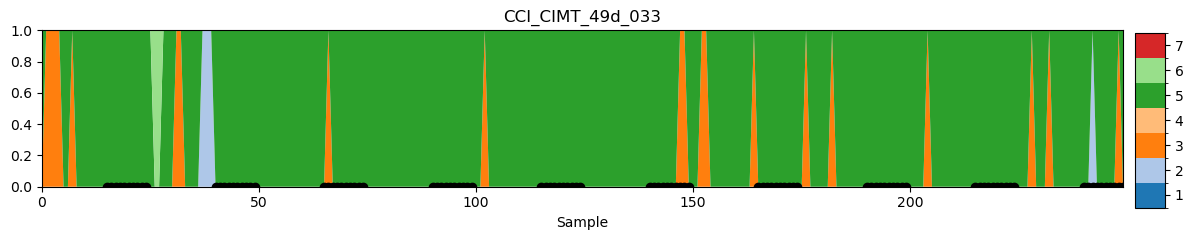

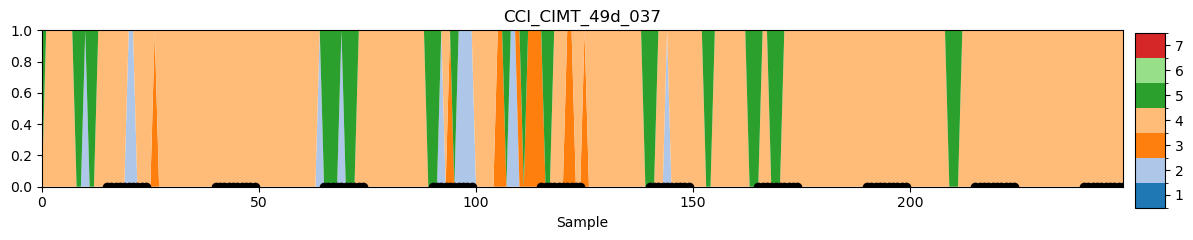

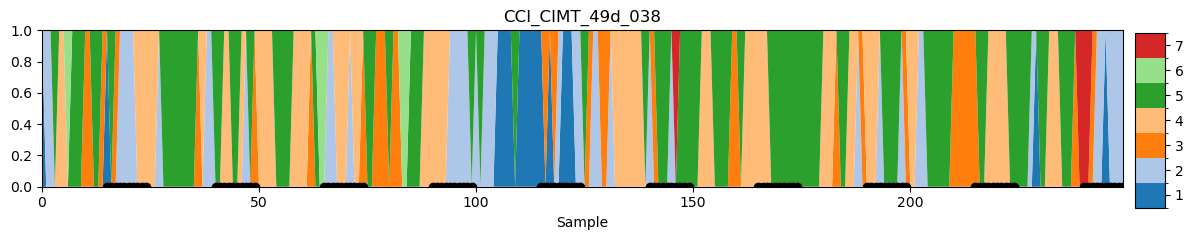

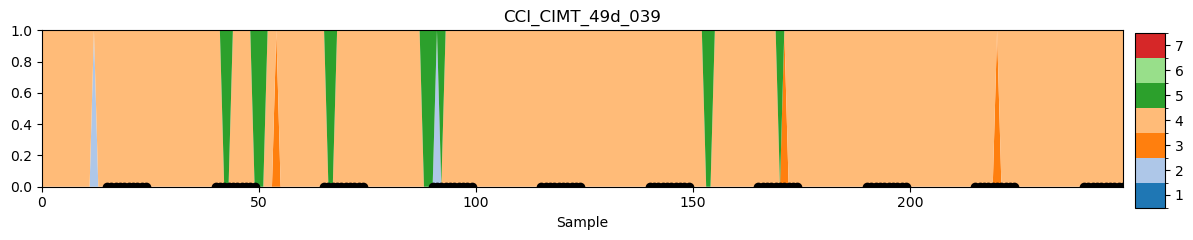

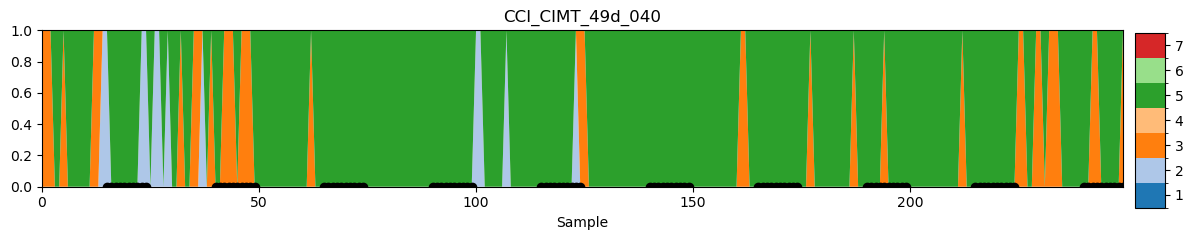

In [72]:
for subj in np.where(y == 'CCI_CIMT_49d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

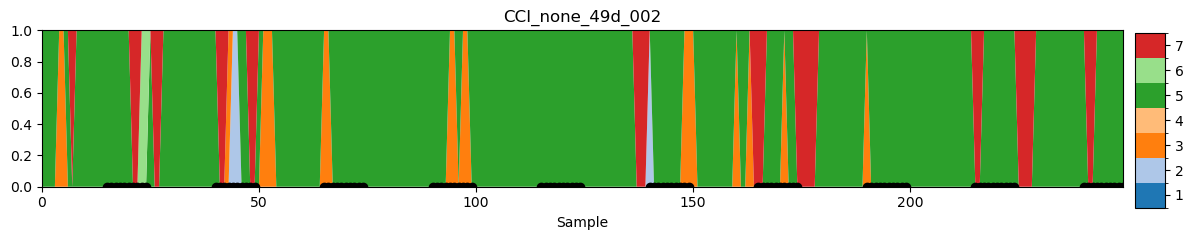

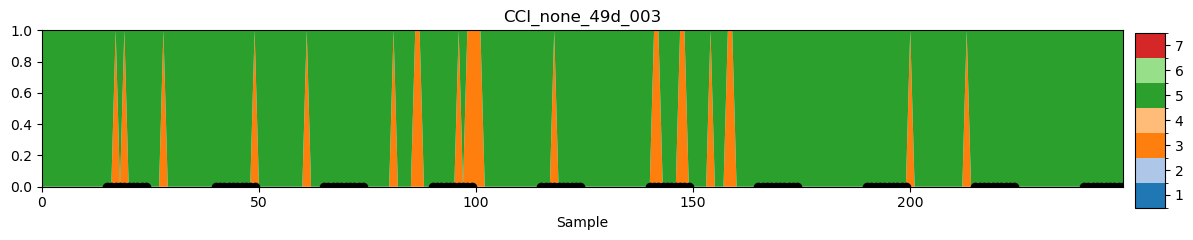

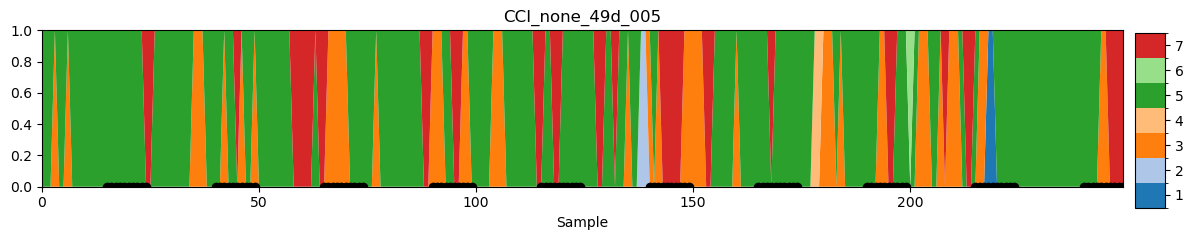

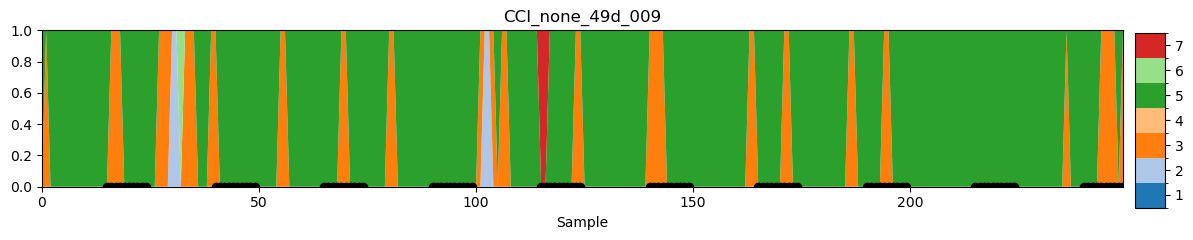

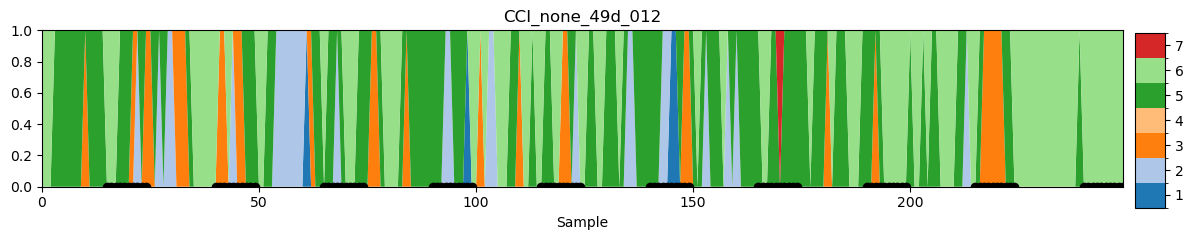

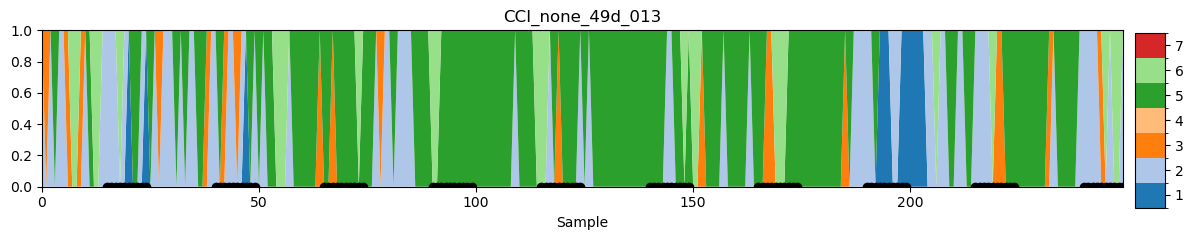

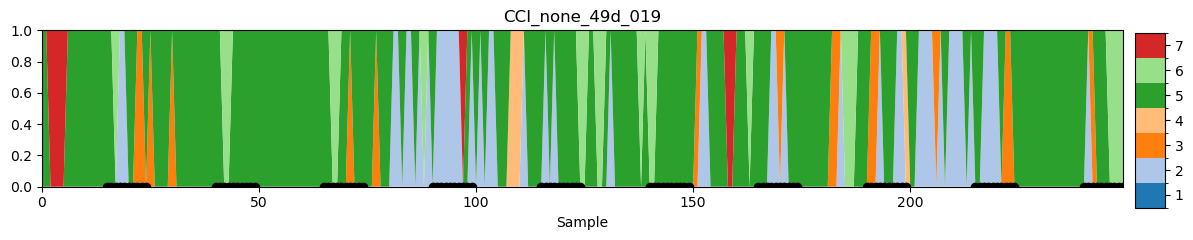

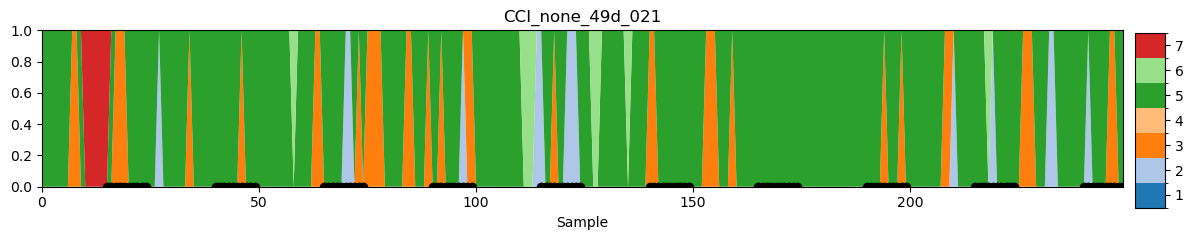

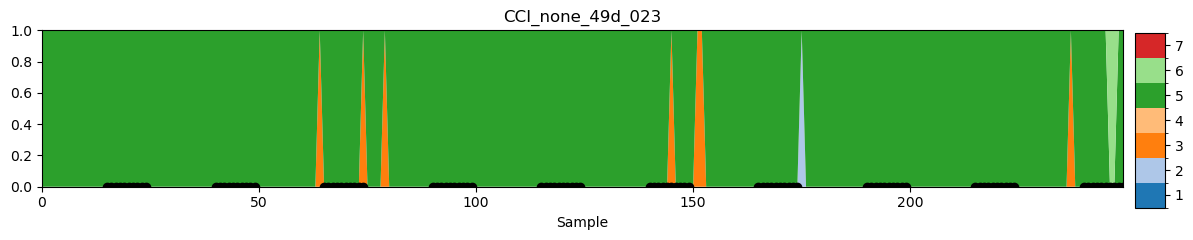

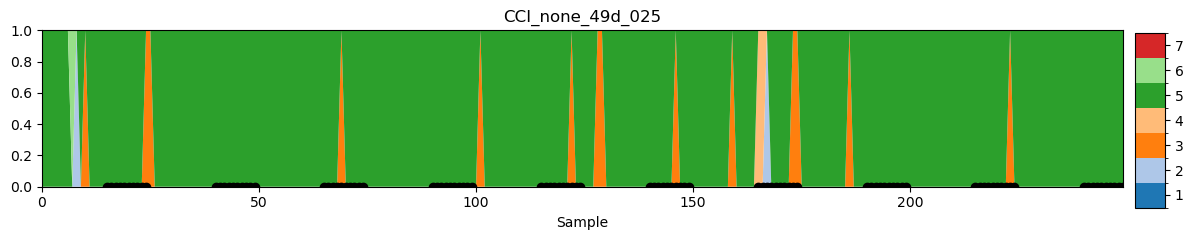

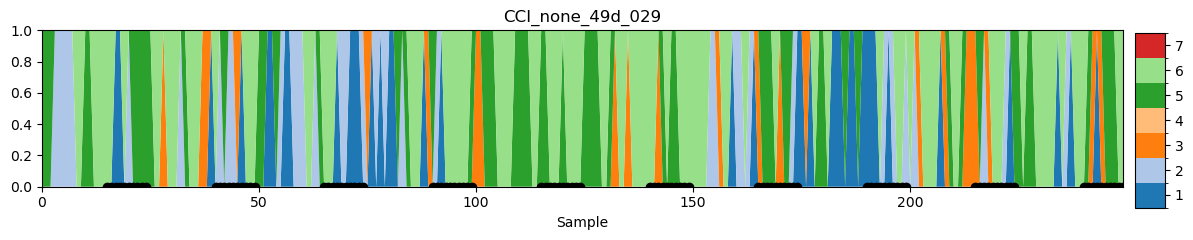

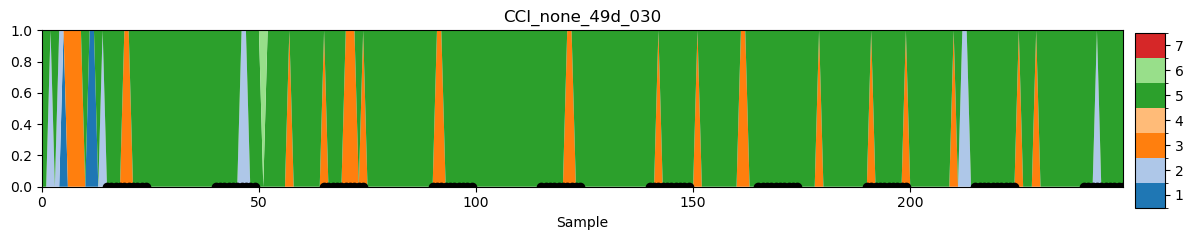

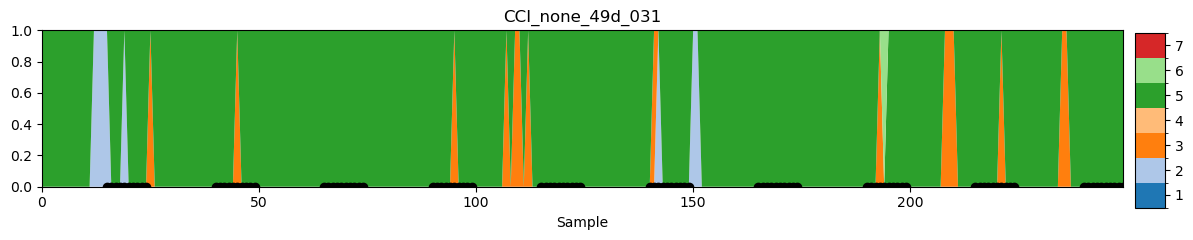

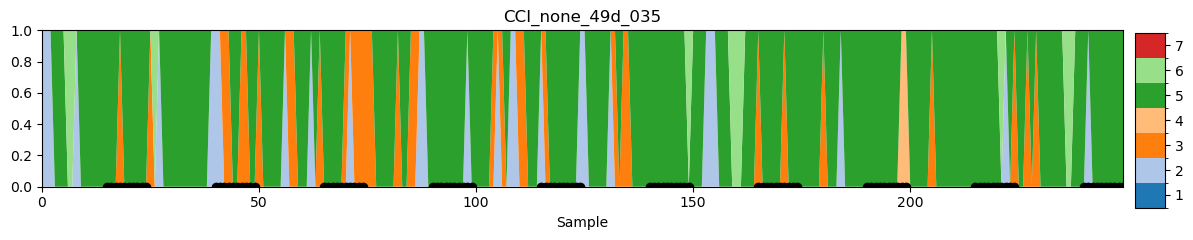

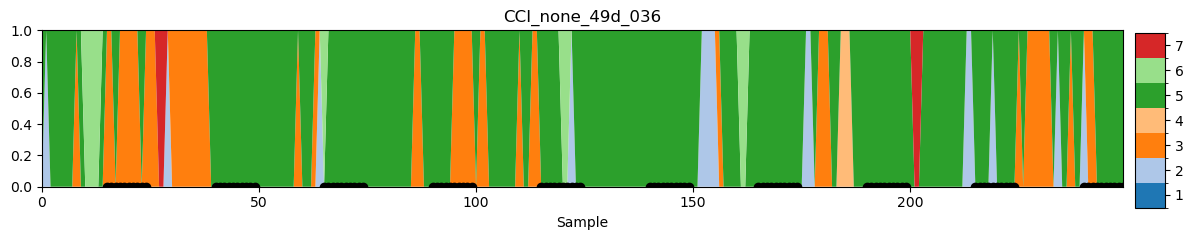

In [73]:
for subj in np.where(y == 'CCI_none_49d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

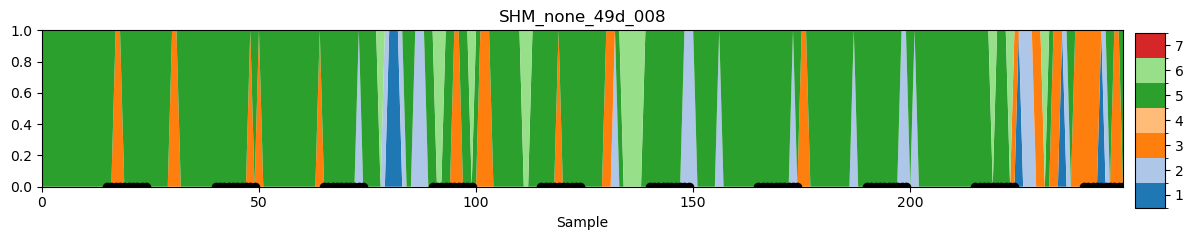

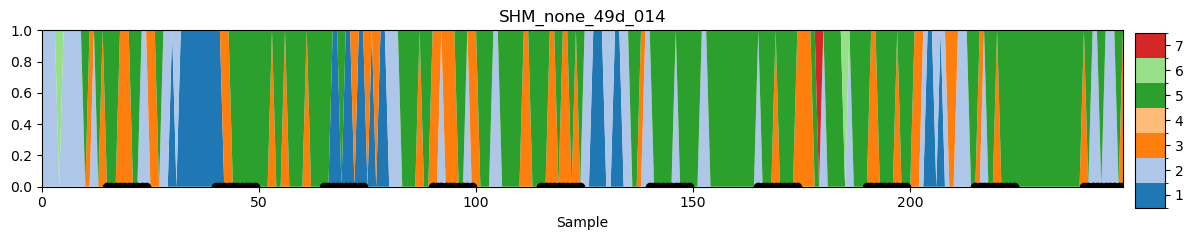

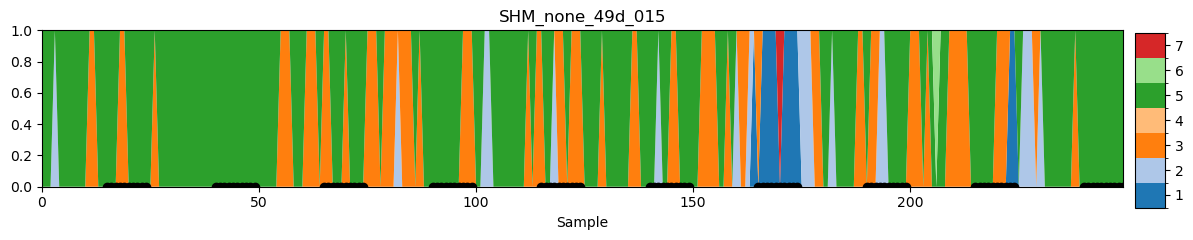

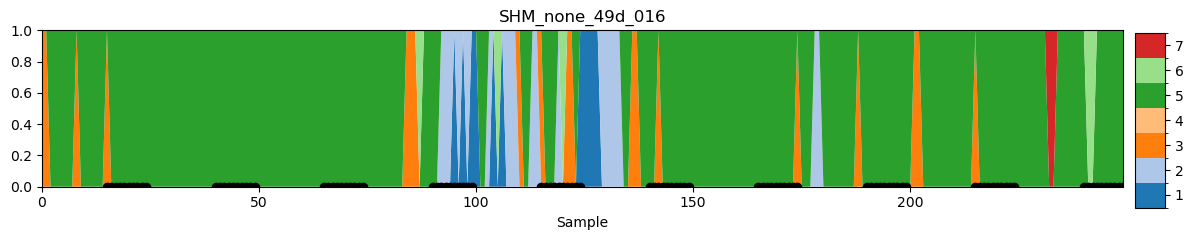

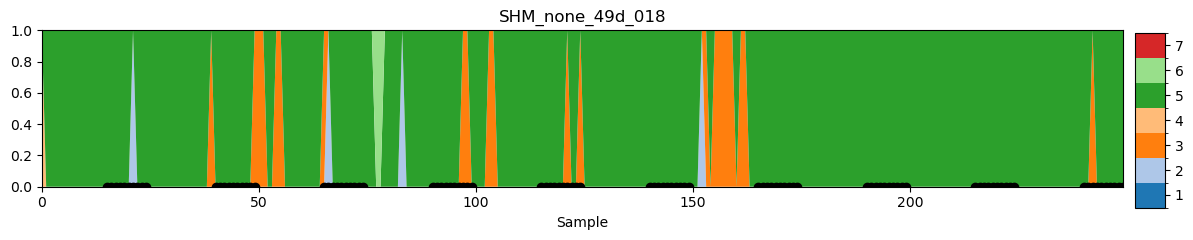

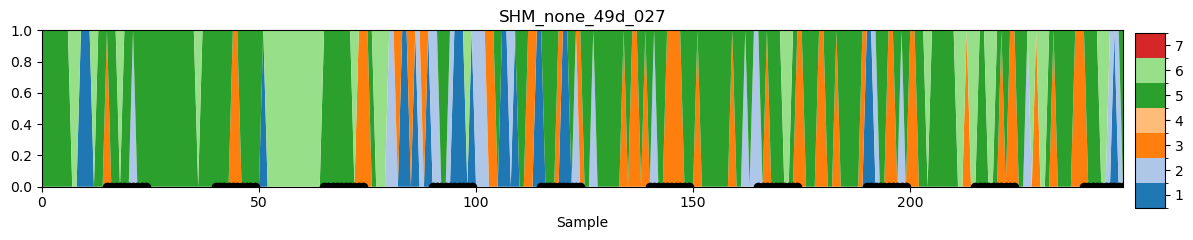

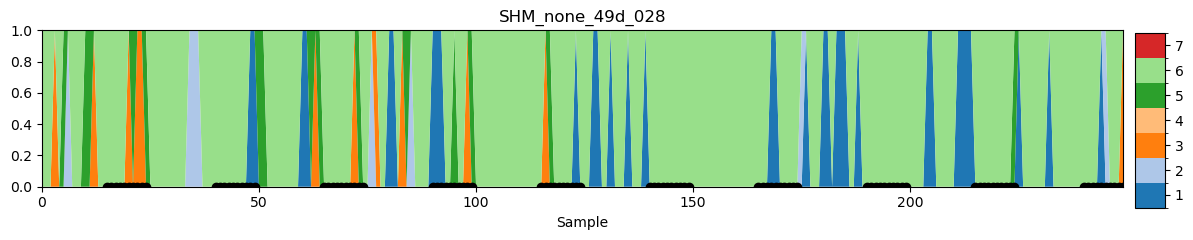

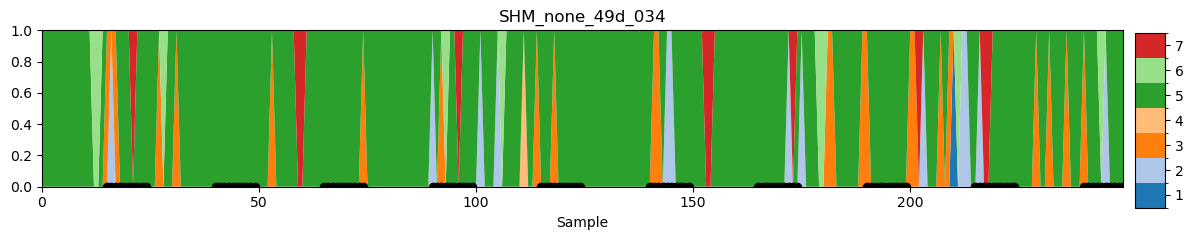

In [74]:
for subj in np.where(y == 'SHM_none_49d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

## Overall Mean State Lifetimes, Intervals, and Switching Rates

[19.19273183 16.83600668 19.06461988 18.70597327 19.63667502 19.61746032
 13.89771018 16.46679198]


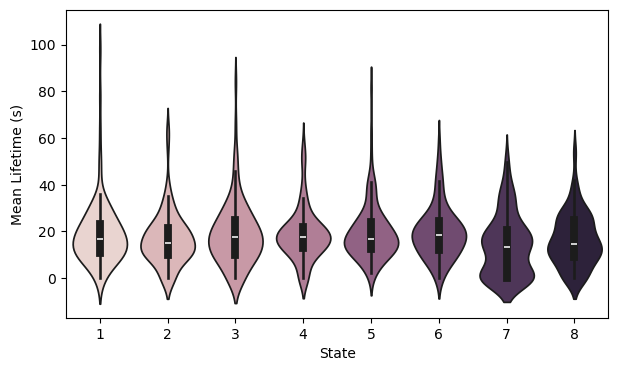

In [157]:
# Calculate mean lifetimes (in seconds)
lt = modes.mean_lifetimes(stc, sampling_frequency=1/2) # TR = 2 s, so sampling_frequency = 1 sample per 2 seconds

# # Convert to ms
# lt *= 1000

# Print the group average
print(np.mean(lt, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(lt.T, x_label="State", y_label="Mean Lifetime (s)")

[106.51988304  87.68174603  79.63070175  88.63897243  82.52778031
  74.12030075  47.69564188  71.85630744]


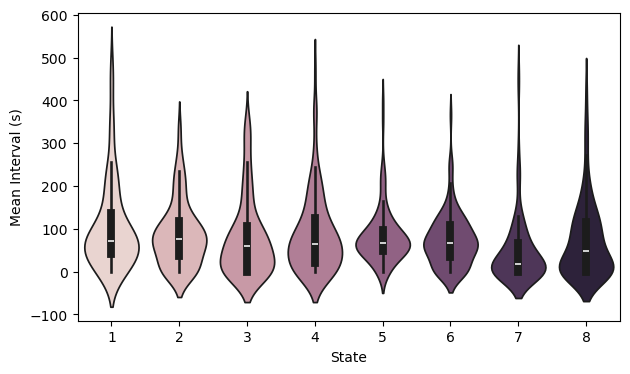

In [158]:
# Calculate mean intervals (in seconds). An interval is the duration between successive visits for a particular state
intv = modes.mean_intervals(stc, sampling_frequency=1/2)

# Print the group average
print(np.mean(intv, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(intv.T, x_label="State", y_label="Mean Interval (s)")

[0.00631579 0.00591228 0.00492982 0.00540351 0.00833333 0.00682456
 0.00517544 0.00438596]


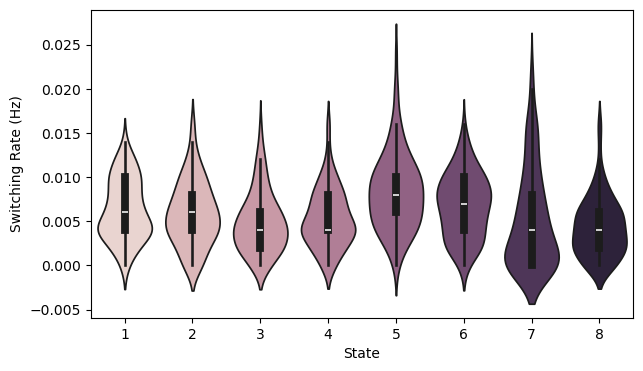

In [159]:
# Calculate the switching rate (Hz). This is defined as the number of state activations per second.
sr = modes.switching_rates(stc, sampling_frequency=1/2)

# Print the group average
print(np.mean(sr, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(sr.T, x_label="State", y_label="Switching Rate (Hz)")

## Within-group FO

In [31]:
groups = {}

for group in np.unique(y):
    groups[group] = {}

In [32]:
def within_group_plotting_helper(metric, y_label):
    fig, ax = plt.subplots(1, 2, sharey=True, figsize=(20, 4))
    plotting.plot_violin(
        np.concatenate((groups['CCI_CIMT_07d'][metric], groups['CCI_none_07d'][metric]), axis=0).T, 
        x_label="State", 
        y_label=y_label, 
        title="injured_07d", 
        ax=ax[0]
    )
    plotting.plot_violin(groups['SHM_none_07d'][metric].T, x_label="State", y_label=y_label, title="SHM_none_07d", ax=ax[1])
    
    for PID in ['07d', '21d', '49d']:
        fig, ax = plt.subplots(1, 3, sharey=True, figsize=(20, 4))
        plotting.plot_violin(groups['CCI_CIMT_' + PID][metric].T, x_label="State", y_label=y_label, title="CCI_CIMT_" + PID, ax=ax[0])
        plotting.plot_violin(groups['CCI_none_' + PID][metric].T, x_label="State", y_label=y_label, title="CCI_none_" + PID, ax=ax[1])
        plotting.plot_violin(groups['SHM_none_' + PID][metric].T, x_label="State", y_label=y_label, title="SHM_none_" + PID, ax=ax[2])

True


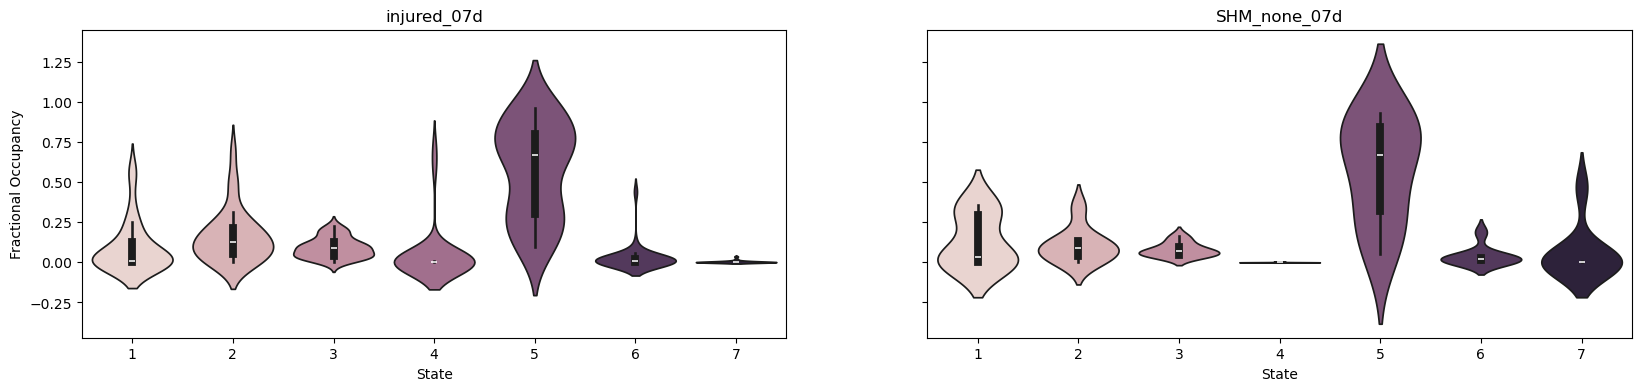

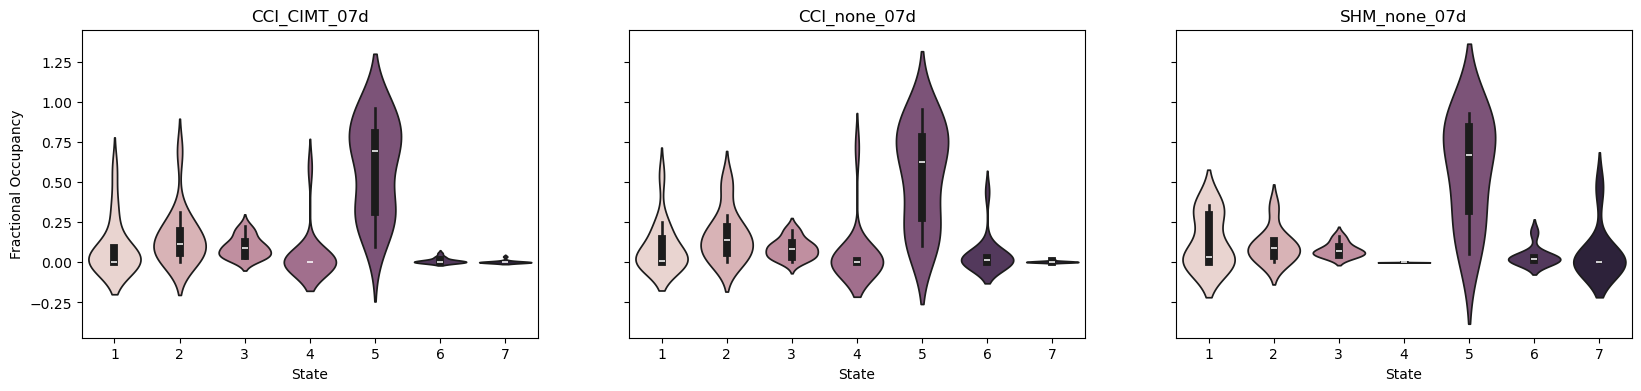

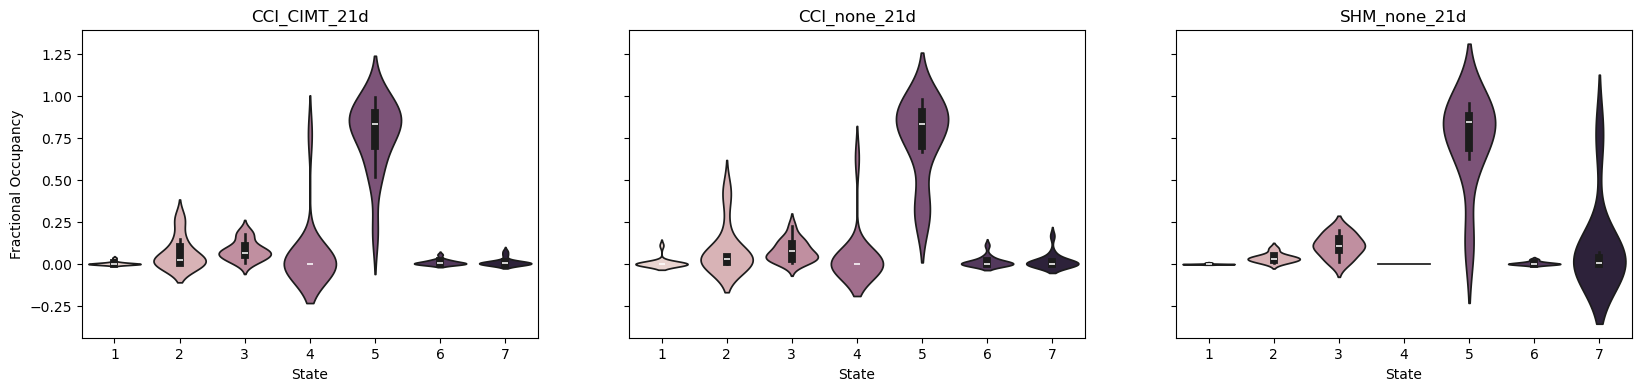

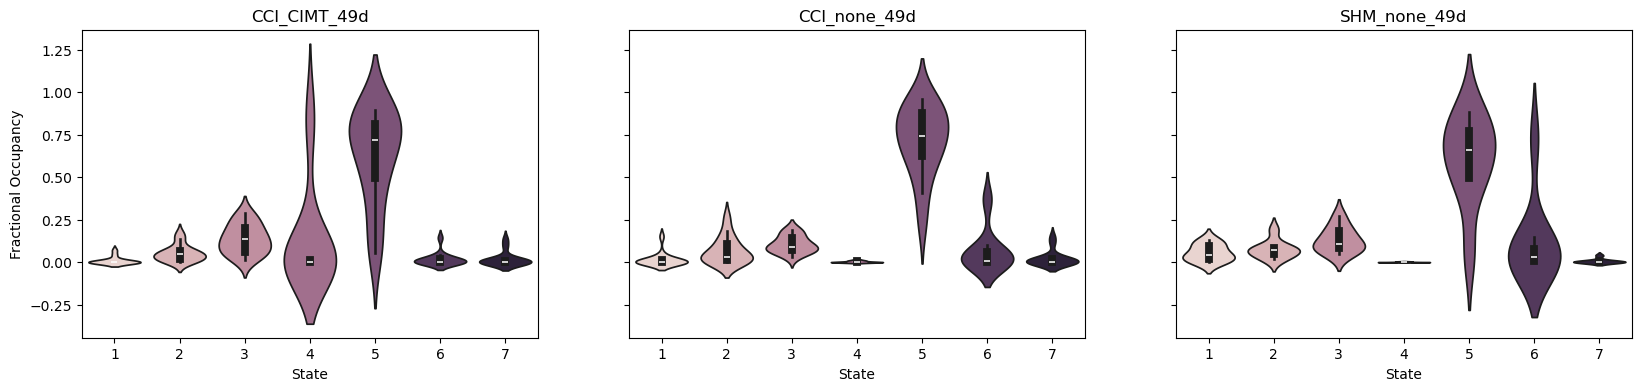

In [33]:
# FO means for each experimental group
for group in groups:
    groups[group]['fo'] = fo[np.where(y == group)]

print(sum([len(groups[group]['fo']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('fo', "Fractional Occupancy")

## Within-group mean state lifetimes

In [34]:
# State time course (STC) for each experimental group
for group in groups:
    groups[group]['stc'] = [stc[i] for i in range(len(stc)) if i in np.where(y == group)[0]]

print(sum([len(groups[group]['stc']) for group in groups]) == full_data.n_sessions)

True


True


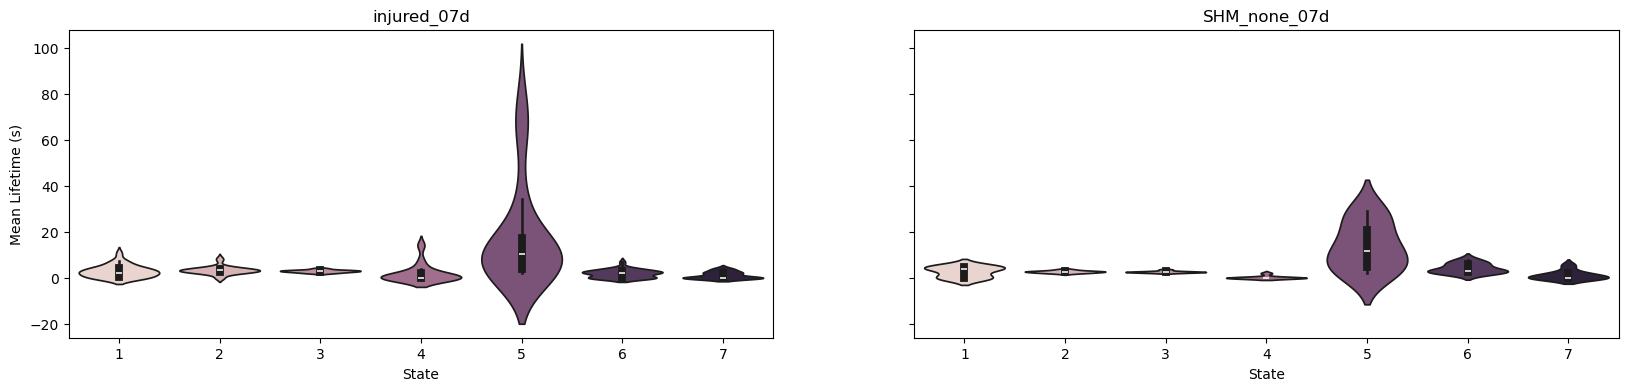

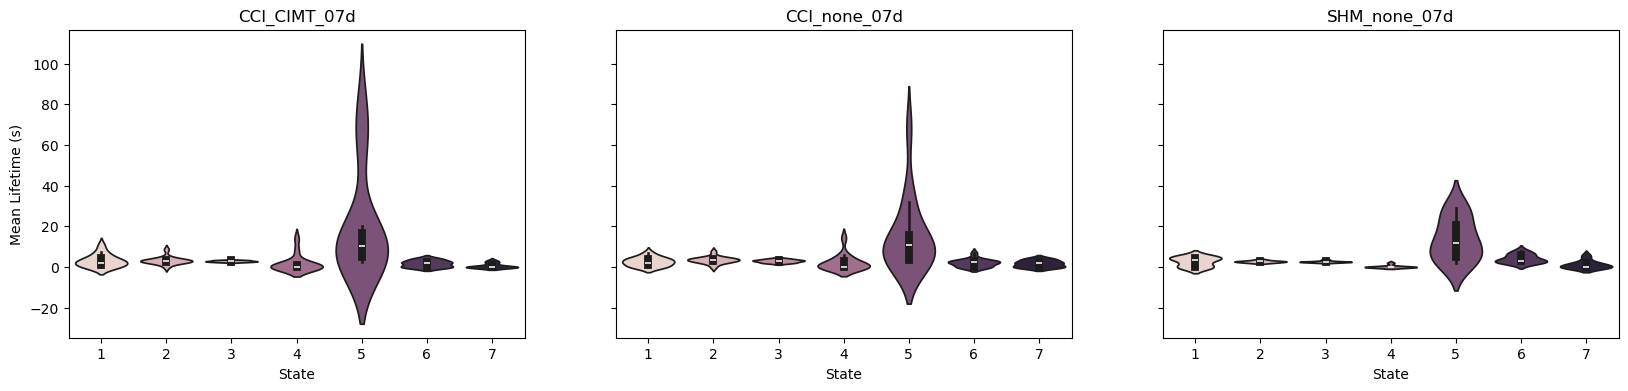

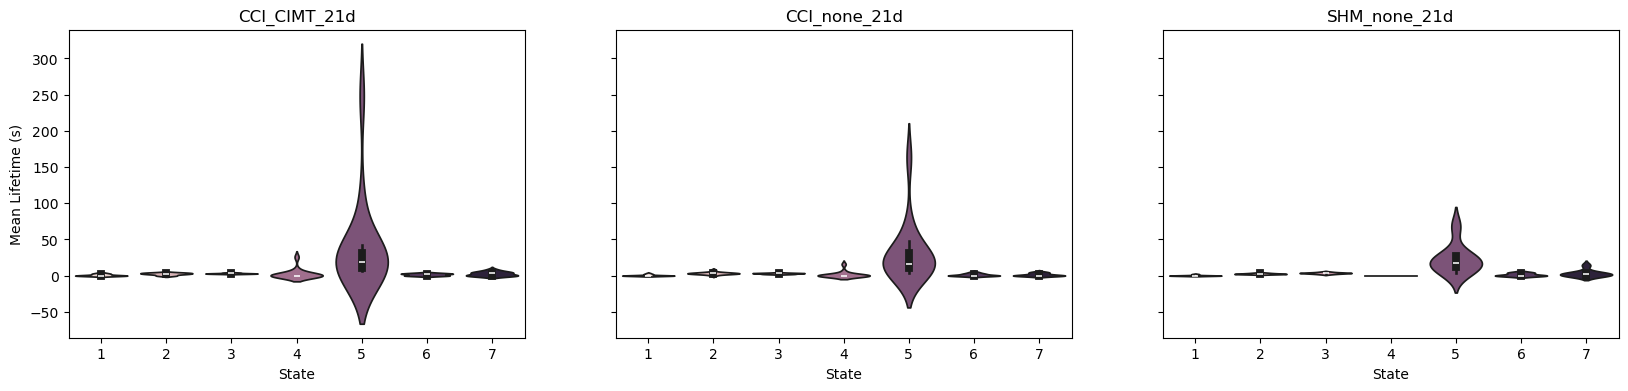

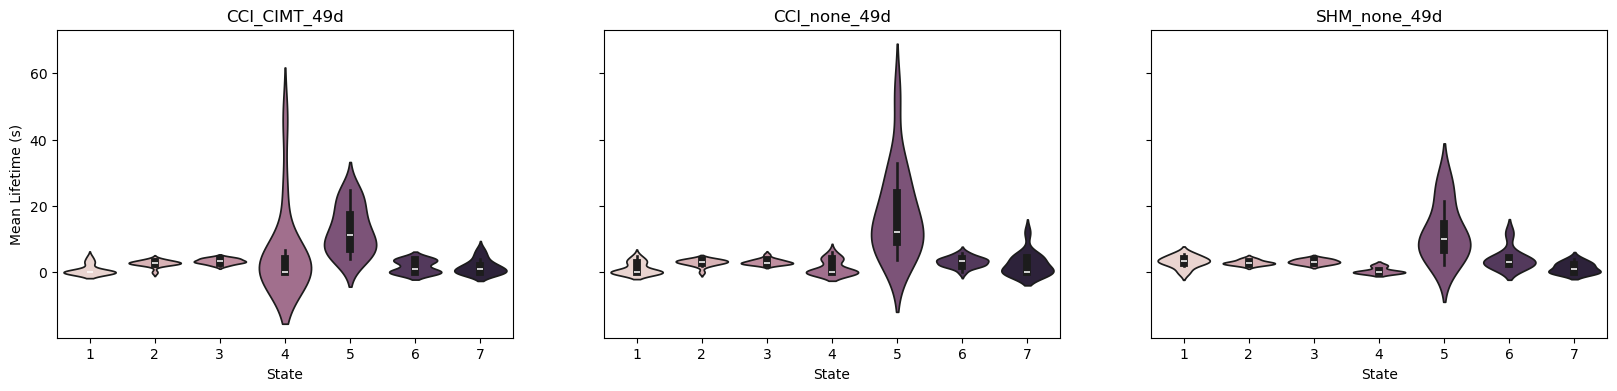

In [35]:
# Calculate mean lifetimes (in seconds) for each experimental group
for group in groups:
    groups[group]['lt'] = modes.mean_lifetimes(groups[group]['stc'], sampling_frequency=1/2) # TR = 2 s, so sampling_frequency = 1 sample per 2 seconds

print(sum([len(groups[group]['lt']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('lt', "Mean Lifetime (s)")

## Within-group mean interstate intervals

True


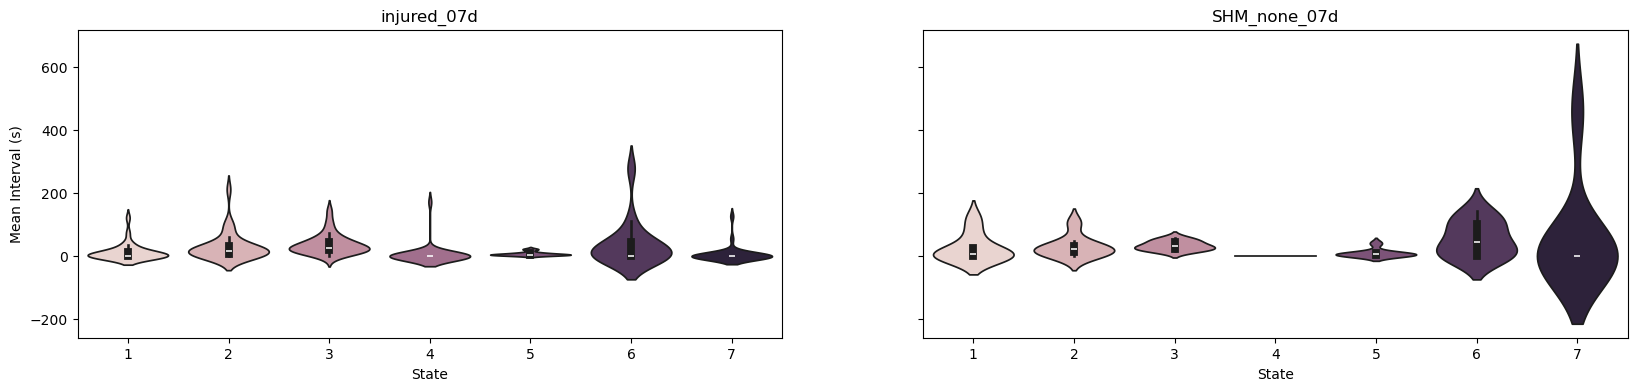

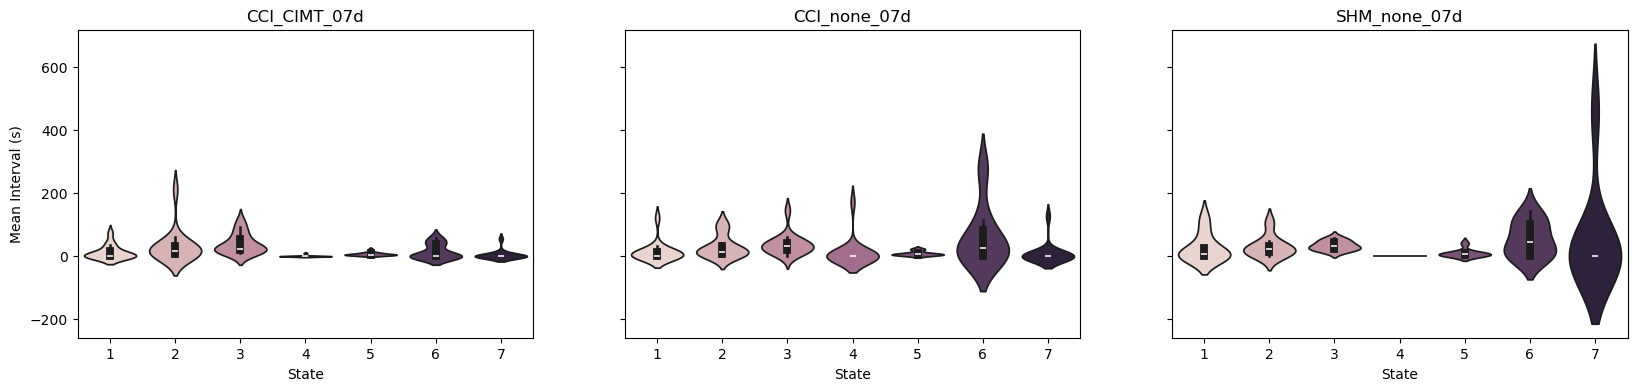

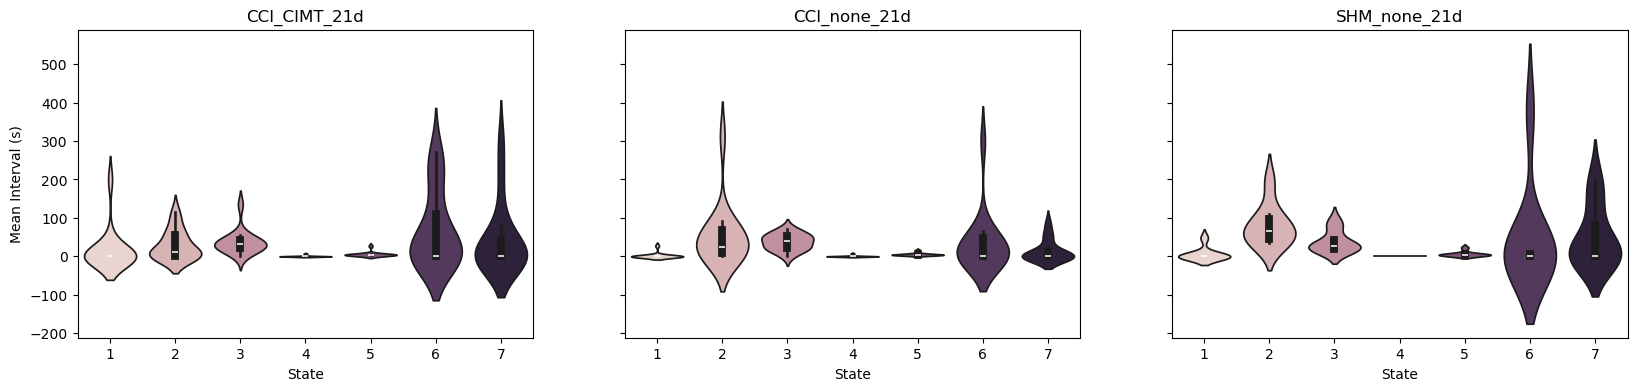

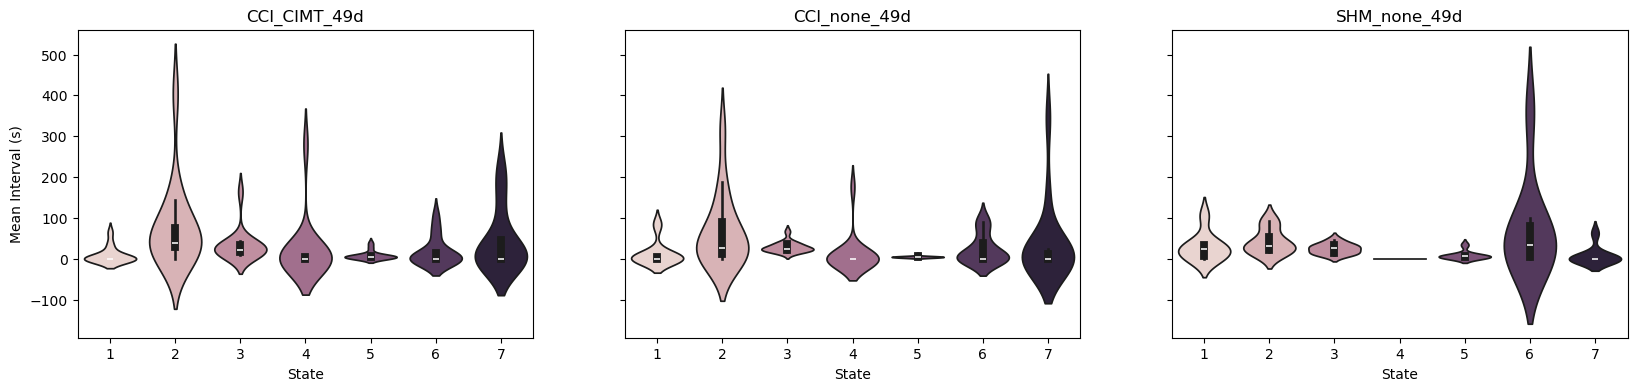

In [36]:
# Calculate mean intervals (in seconds) for each experimental group
for group in groups:
    groups[group]['intv'] = modes.mean_intervals(groups[group]['stc'], sampling_frequency=1/2)

print(sum([len(groups[group]['intv']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('intv', "Mean Interval (s)")

## Within-group switching rate 

True


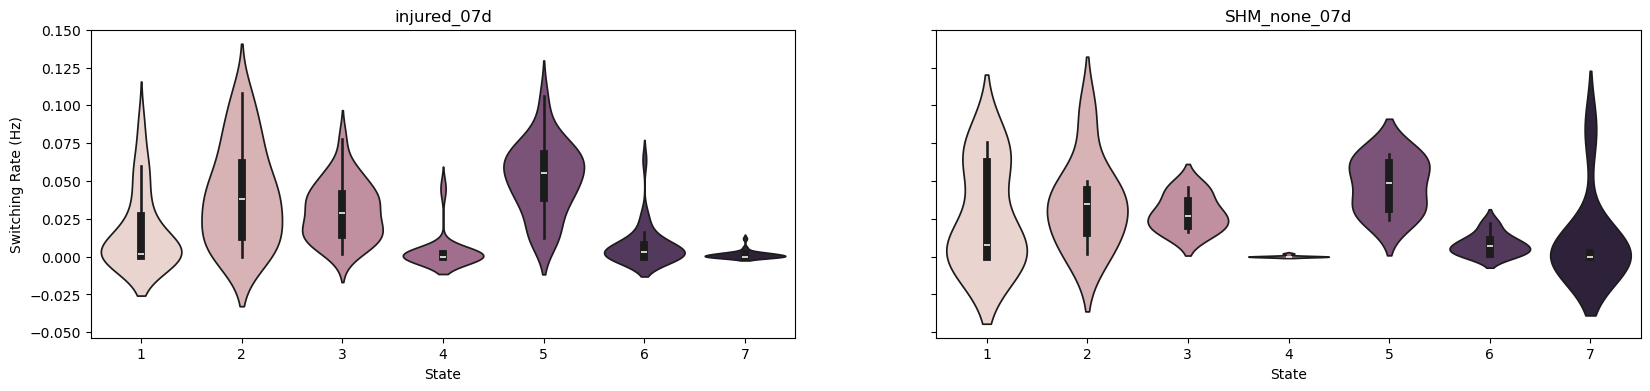

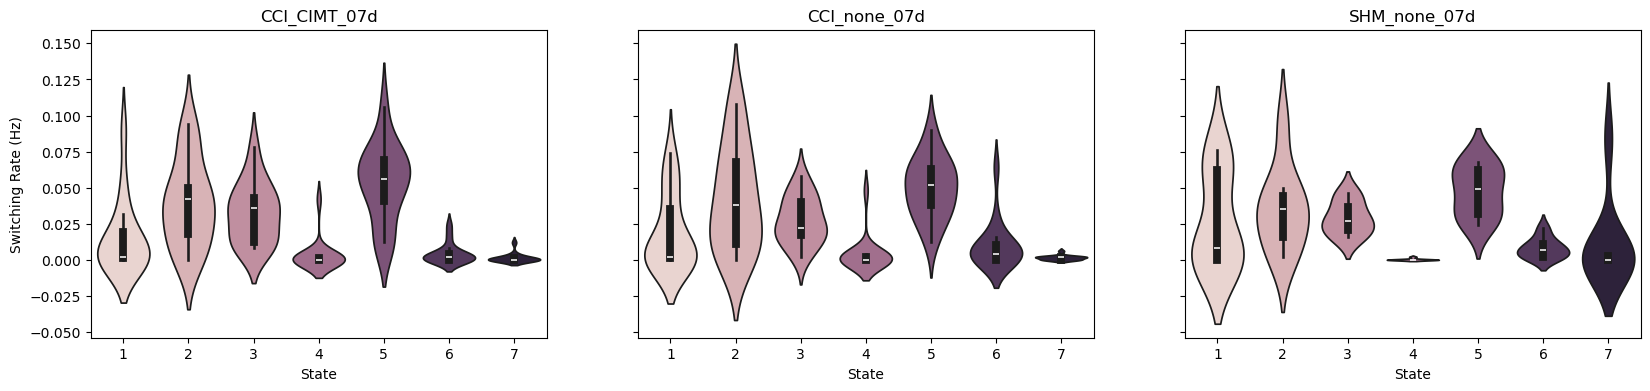

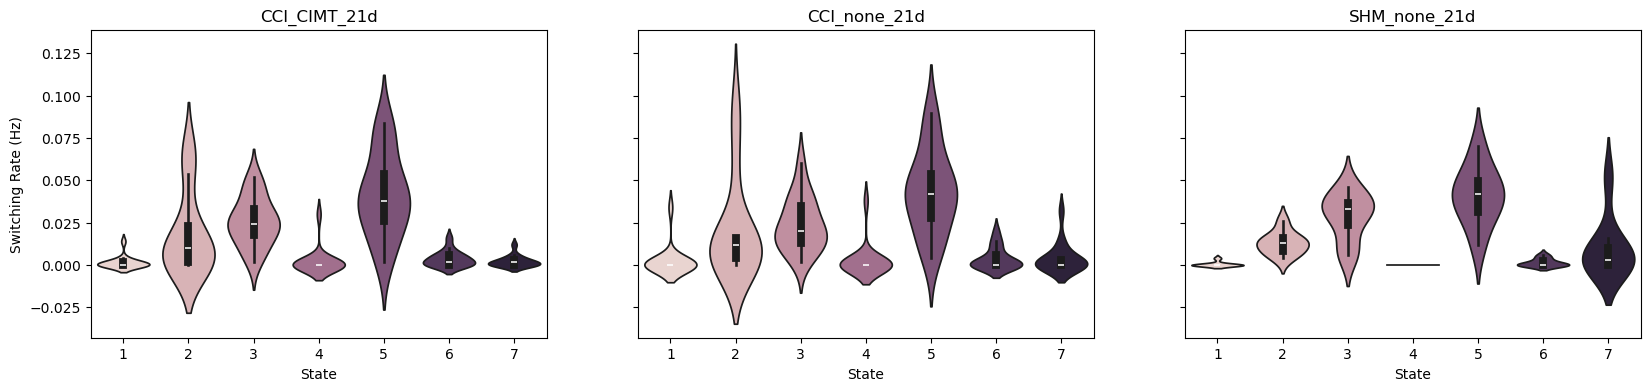

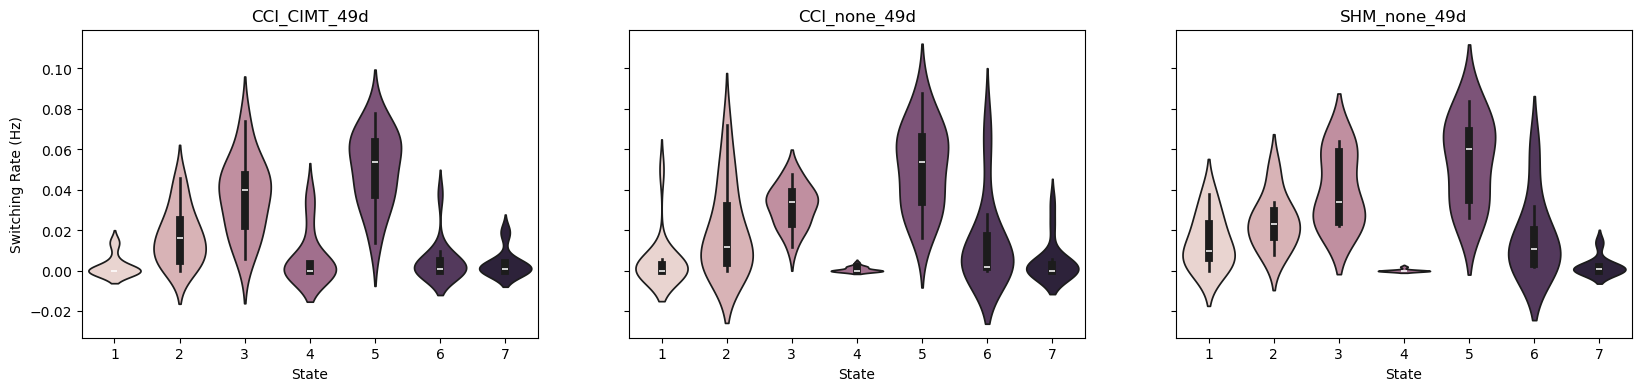

In [37]:
# Calculate the switching rate (Hz)
for group in groups:
    groups[group]['sr'] = modes.switching_rates(groups[group]['stc'], sampling_frequency=1/2)

print(sum([len(groups[group]['sr']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('sr', "Switching Rate (Hz)")

## Subject-Level Transition Probability Matrices

In [38]:
subj_trans_matrices = post_hoc.calc_trans_prob_matrix(list(stc), n_states=k_optimal)
subj_trans_matrices.shape

(113, 7, 7)

In [39]:
for group in groups:
    # Store transition matrices of all subjects in the group
    group_trans_matrices = subj_trans_matrices[np.where(y == group)]
    groups[group]['trans_matrices'] = group_trans_matrices
    print(group_trans_matrices.shape)
    
    # Store mean transition matrix of the group
    groups[group]['mean_trans_matrix'] = np.mean(group_trans_matrices, axis=0)
    print(groups[group]['mean_trans_matrix'].shape)

(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(14, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(8, 7, 7)
(7, 7)
(8, 7, 7)
(7, 7)
(8, 7, 7)
(7, 7)


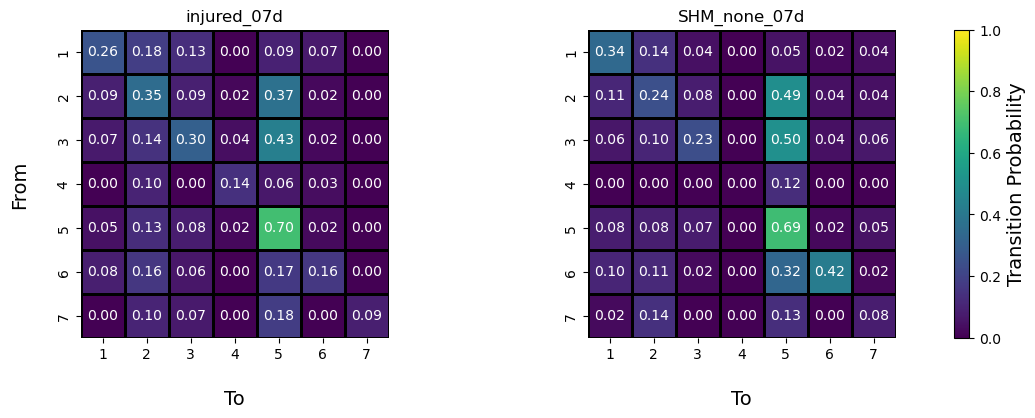

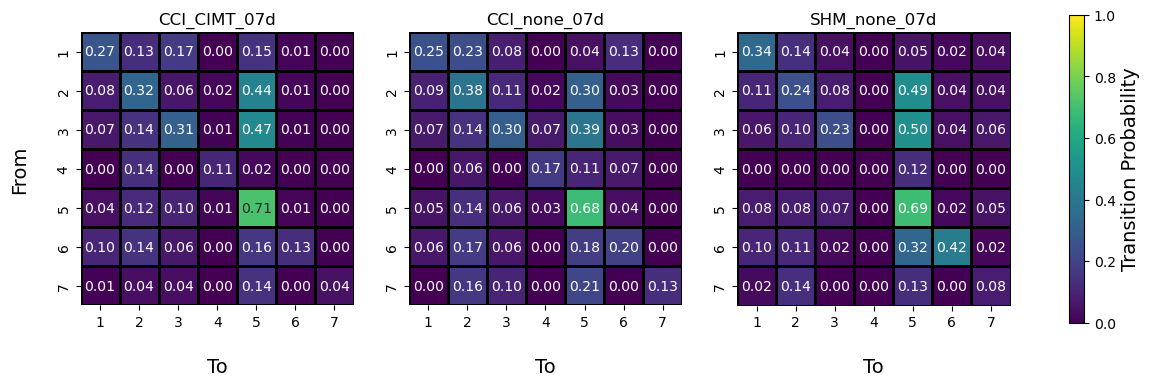

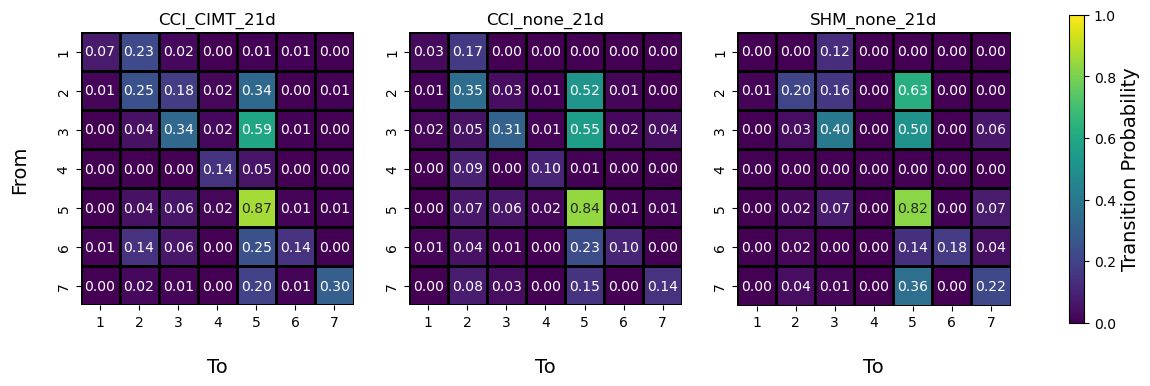

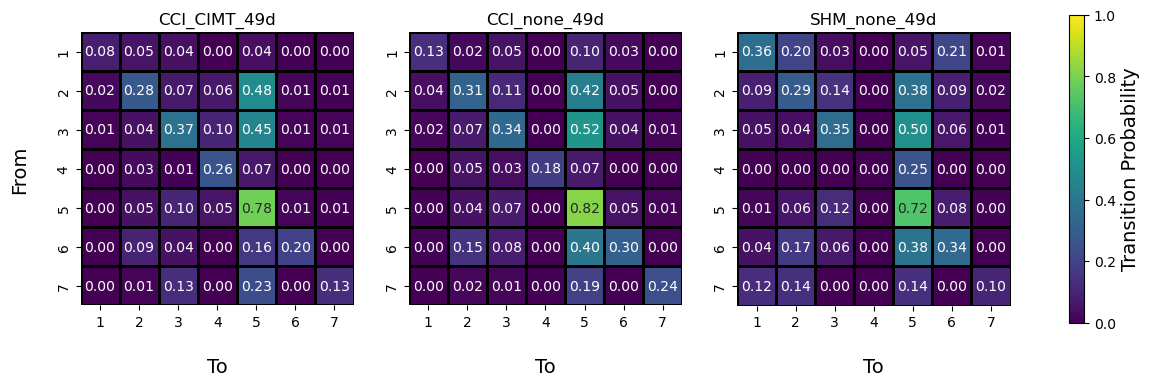

In [40]:
def heatmap_wrapper(data, ax):
    return sns.heatmap(
        data,
        cmap='viridis',
        linecolor='black',
        linewidths=1,
        cbar=False,
        annot=True,
        square=True,
        vmin=0,
        vmax=1,
        center=0.5,
        fmt='.2f',
        ax=ax,
    )

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
im = heatmap_wrapper(np.mean(subj_trans_matrices[np.where((y == 'CCI_CIMT_07d') | (y == 'CCI_none_07d'))], axis=0), axs[0])
im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
im.set_ylabel('From',fontsize=14,fontweight='regular',labelpad=20)
im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
axs[0].set_title("injured_07d")

im = heatmap_wrapper(groups['SHM_none_07d']['mean_trans_matrix'], ax=axs[1])
im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
axs[1].set_title('SHM_none_07d')

cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='vertical')
cbar.set_label('Transition Probability', fontsize=14)
plt.show()

for PID in ['07d', '21d', '49d']:
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    im = heatmap_wrapper(groups['CCI_CIMT_' + PID]['mean_trans_matrix'], ax=axs[0])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_ylabel('From',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    axs[0].set_title("CCI_CIMT_" + PID)

    im = heatmap_wrapper(groups['CCI_none_' + PID]['mean_trans_matrix'], ax=axs[1])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    axs[1].set_title("CCI_none_" + PID)
    
    im = heatmap_wrapper(groups['SHM_none_' + PID]['mean_trans_matrix'], ax=axs[2])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    axs[2].set_title("SHM_none_" + PID)

    cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='vertical')
    cbar.set_label('Transition Probability', fontsize=14)
    plt.show()

# Hypothesis Testing

In [50]:
ht_df = create_hypothesis_testing_dataframe(
    group_data=groups, 
    group_labels=list(np.unique(y)),
    metrics=['fo', 'lt', 'intv', 'sr'],
    k=k_optimal,
)

tp_df = separate_trans_probs(
    group_data=groups, 
    group_labels=list(np.unique(y)),
    k=k_optimal,
)

ht_df = ht_df.drop(columns=['group'])
ht_df = pd.concat([ht_df, tp_df], axis=1)
ht_df['condition'] = ht_df['group'].map(lambda g: 'injured' if 'CCI' in g else 'healthy')
print(ht_df.shape)
print(ht_df.columns)
ht_df

(113, 79)
Index(['fo_state1', 'fo_state2', 'fo_state3', 'fo_state4', 'fo_state5',
       'fo_state6', 'fo_state7', 'lt_state1', 'lt_state2', 'lt_state3',
       'lt_state4', 'lt_state5', 'lt_state6', 'lt_state7', 'intv_state1',
       'intv_state2', 'intv_state3', 'intv_state4', 'intv_state5',
       'intv_state6', 'intv_state7', 'sr_state1', 'sr_state2', 'sr_state3',
       'sr_state4', 'sr_state5', 'sr_state6', 'sr_state7', 'tp_1to1',
       'tp_1to2', 'tp_1to3', 'tp_1to4', 'tp_1to5', 'tp_1to6', 'tp_1to7',
       'tp_2to1', 'tp_2to2', 'tp_2to3', 'tp_2to4', 'tp_2to5', 'tp_2to6',
       'tp_2to7', 'tp_3to1', 'tp_3to2', 'tp_3to3', 'tp_3to4', 'tp_3to5',
       'tp_3to6', 'tp_3to7', 'tp_4to1', 'tp_4to2', 'tp_4to3', 'tp_4to4',
       'tp_4to5', 'tp_4to6', 'tp_4to7', 'tp_5to1', 'tp_5to2', 'tp_5to3',
       'tp_5to4', 'tp_5to5', 'tp_5to6', 'tp_5to7', 'tp_6to1', 'tp_6to2',
       'tp_6to3', 'tp_6to4', 'tp_6to5', 'tp_6to6', 'tp_6to7', 'tp_7to1',
       'tp_7to2', 'tp_7to3', 'tp_7to4', 'tp_7to5

,fo_state1,fo_state2,fo_state3,fo_state4,fo_state5,fo_state6,fo_state7,lt_state1,lt_state2,lt_state3,...,tp_6to7,tp_7to1,tp_7to2,tp_7to3,tp_7to4,tp_7to5,tp_7to6,tp_7to7,group,condition
0,0.008,0.092,0.140,0.000,0.752,0.004,0.004,4.000000,3.285714,2.916667,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,CCI_CIMT_07d,injured
1,0.000,0.008,0.032,0.000,0.960,0.000,0.000,0.000000,2.000000,3.200000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CCI_CIMT_07d,injured
2,0.004,0.040,0.076,0.016,0.856,0.008,0.000,2.000000,2.500000,2.533333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CCI_CIMT_07d,injured
3,0.000,0.076,0.040,0.592,0.292,0.000,0.000,0.000000,3.454545,2.857143,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CCI_CIMT_07d,injured
4,0.004,0.692,0.024,0.000,0.264,0.016,0.000,2.000000,8.650000,2.400000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CCI_CIMT_07d,injured
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,0.044,0.076,0.076,0.000,0.776,0.020,0.008,3.666667,4.222222,2.923077,...,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,SHM_none_49d,healthy
109,0.000,0.016,0.088,0.004,0.884,0.008,0.000,0.000000,2.000000,3.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SHM_none_49d,healthy
110,0.088,0.088,0.180,0.000,0.496,0.148,0.000,3.384615,2.588235,3.103448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SHM_none_49d,healthy
111,0.132,0.032,0.048,0.000,0.060,0.728,0.000,3.473684,2.666667,2.181818,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SHM_none_49d,healthy


## Between Groups

### 07d

Note that CIMT treatment began after 07d

In [52]:
ht_df_07d = ht_df.loc[ht_df['group'].str.find('07d') != -1]
ht_df_07d['group'].unique()

array([np.str_('CCI_CIMT_07d'), np.str_('CCI_none_07d'),
       np.str_('SHM_none_07d')], dtype=object)

In [53]:
# FO
permtest_ind(
    data=ht_df_07d[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,healthy,injured,0.586486,0.538746,t-test,0.239727,0.007143,False
1,fo_state2,healthy,injured,-0.900538,0.392961,t-test,0.366110,0.007143,False
2,fo_state3,healthy,injured,-0.511712,0.635736,t-test,0.208143,0.007143,False
3,fo_state4,healthy,injured,-0.764431,0.268373,t-test,0.309376,0.007143,False
4,fo_state5,healthy,injured,0.066890,0.956104,t-test,0.027371,0.007143,False
5,fo_state6,healthy,injured,0.362650,0.511749,t-test,0.147602,0.007143,False
6,fo_state7,healthy,injured,0.960364,0.346365,welch,0.819452,0.007143,False


In [54]:
# State lifetimes
permtest_ind(
    data=ht_df_07d[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,healthy,injured,-0.188030,0.877712,t-test,0.076677,0.007143,False
1,lt_state2,healthy,injured,-1.042705,0.289371,t-test,0.422408,0.007143,False
2,lt_state3,healthy,injured,-1.372428,0.176182,t-test,0.558316,0.007143,False
3,lt_state4,healthy,injured,-2.256010,0.268373,welch,0.493106,0.007143,False
4,lt_state5,healthy,injured,-0.543939,0.650135,t-test,0.220673,0.007143,False
5,lt_state6,healthy,injured,3.194828,0.005399,t-test,1.309426,0.007143,True
6,lt_state7,healthy,injured,0.003902,0.962904,t-test,0.001602,0.007143,False


In [55]:
# Interstate intervals
permtest_ind(
    data=ht_df_07d[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,healthy,injured,1.074419,0.307369,t-test,0.443252,0.007143,False
1,intv_state2,healthy,injured,-0.016082,0.862514,t-test,0.006548,0.007143,False
2,intv_state3,healthy,injured,-0.391010,0.758524,t-test,0.158622,0.007143,False
3,intv_state4,healthy,injured,-0.557578,0.956504,t-test,0.225660,0.007143,False
4,intv_state5,healthy,injured,0.678690,0.482752,t-test,0.281572,0.007143,False
5,intv_state6,healthy,injured,0.554271,0.576742,t-test,0.225665,0.007143,False
6,intv_state7,healthy,injured,0.898648,0.236176,welch,0.733889,0.007143,False


In [56]:
# Switching rates
permtest_ind(
    data=ht_df_07d[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,healthy,injured,0.903979,0.385361,t-test,0.371112,0.007143,False
1,sr_state2,healthy,injured,-0.425487,0.695130,t-test,0.173539,0.007143,False
2,sr_state3,healthy,injured,-0.153720,0.921308,t-test,0.062466,0.007143,False
3,sr_state4,healthy,injured,-0.827461,0.375762,t-test,0.334900,0.007143,False
4,sr_state5,healthy,injured,-0.475734,0.647135,t-test,0.193636,0.007143,False
5,sr_state6,healthy,injured,0.191861,0.697530,t-test,0.077896,0.007143,False
6,sr_state7,healthy,injured,0.945715,0.312169,welch,0.798586,0.007143,False


In [57]:
# Transition probabilities
permtest_ind(
    data=ht_df_07d[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/miniforge3/envs/osld/lib/python3.12/site-packages/scipy/stats/_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:189: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean/s_pooled


,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,healthy,injured,0.655088,0.528747,t-test,0.267506,0.00102,False
1,tp_1to2,healthy,injured,-0.395934,0.803920,t-test,0.160624,0.00102,False
2,tp_1to3,healthy,injured,-0.809975,0.648535,t-test,0.327968,0.00102,False
3,tp_1to4,healthy,injured,NaN,0.000200,welch,NaN,0.00102,True
4,tp_1to5,healthy,injured,-0.615277,0.696130,t-test,0.249334,0.00102,False
5,tp_1to6,healthy,injured,-0.662814,0.683132,t-test,0.268339,0.00102,False
6,tp_1to7,healthy,injured,0.969685,0.427957,welch,0.825230,0.00102,False
7,tp_2to1,healthy,injured,0.434013,0.643336,t-test,0.176987,0.00102,False
8,tp_2to2,healthy,injured,-1.310589,0.188581,t-test,0.532670,0.00102,False
9,tp_2to3,healthy,injured,-0.191459,0.940906,t-test,0.077915,0.00102,False


### 21d

#### CCI Only

In [59]:
ht_df_21d_CCI = ht_df.loc[(ht_df['group'].str.find('21d') != -1) & (ht_df['group'].str.startswith('CCI'))]
ht_df_21d_CCI['group'].unique()

array([np.str_('CCI_CIMT_21d'), np.str_('CCI_none_21d')], dtype=object)

In [60]:
# FO
permtest_ind(
    data=ht_df_21d_CCI[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_CIMT_21d,CCI_none_21d,-0.476723,0.974103,t-test,0.180185,0.007143,False
1,fo_state2,CCI_CIMT_21d,CCI_none_21d,-0.488925,0.647135,t-test,0.184796,0.007143,False
2,fo_state3,CCI_CIMT_21d,CCI_none_21d,0.133767,0.898710,t-test,0.050559,0.007143,False
3,fo_state4,CCI_CIMT_21d,CCI_none_21d,0.148613,0.690931,t-test,0.056170,0.007143,False
4,fo_state5,CCI_CIMT_21d,CCI_none_21d,0.281425,0.776122,t-test,0.106369,0.007143,False
5,fo_state6,CCI_CIMT_21d,CCI_none_21d,-0.452238,0.742126,t-test,0.170930,0.007143,False
6,fo_state7,CCI_CIMT_21d,CCI_none_21d,-0.516559,0.702130,t-test,0.195241,0.007143,False


In [61]:
# State lifetimes
permtest_ind(
    data=ht_df_21d_CCI[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_CIMT_21d,CCI_none_21d,0.928743,0.386961,t-test,0.351032,0.007143,False
1,lt_state2,CCI_CIMT_21d,CCI_none_21d,-1.501924,0.148185,t-test,0.567674,0.007143,False
2,lt_state3,CCI_CIMT_21d,CCI_none_21d,0.208186,0.840316,t-test,0.078687,0.007143,False
3,lt_state4,CCI_CIMT_21d,CCI_none_21d,0.448905,0.690931,t-test,0.169670,0.007143,False
4,lt_state5,CCI_CIMT_21d,CCI_none_21d,0.412304,0.704930,t-test,0.155836,0.007143,False
5,lt_state6,CCI_CIMT_21d,CCI_none_21d,0.709959,0.467353,t-test,0.268339,0.007143,False
6,lt_state7,CCI_CIMT_21d,CCI_none_21d,1.367042,0.189981,t-test,0.516693,0.007143,False


In [62]:
# Interstate intervals
permtest_ind(
    data=ht_df_21d_CCI[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_CIMT_21d,CCI_none_21d,1.096377,0.483952,welch,0.414392,0.007143,False
1,intv_state2,CCI_CIMT_21d,CCI_none_21d,-1.054205,0.349365,t-test,0.398452,0.007143,False
2,intv_state3,CCI_CIMT_21d,CCI_none_21d,-0.107321,0.919508,t-test,0.040564,0.007143,False
3,intv_state4,CCI_CIMT_21d,CCI_none_21d,-0.065824,1.000000,t-test,0.024879,0.007143,False
4,intv_state5,CCI_CIMT_21d,CCI_none_21d,0.197304,0.878312,t-test,0.074574,0.007143,False
5,intv_state6,CCI_CIMT_21d,CCI_none_21d,1.086639,0.287971,t-test,0.410711,0.007143,False
6,intv_state7,CCI_CIMT_21d,CCI_none_21d,1.241762,0.260974,welch,0.469342,0.007143,False


In [63]:
# Switching rates
permtest_ind(
    data=ht_df_21d_CCI[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_CIMT_21d,CCI_none_21d,-0.382044,0.967903,t-test,0.144399,0.007143,False
1,sr_state2,CCI_CIMT_21d,CCI_none_21d,-0.295945,0.777922,t-test,0.111857,0.007143,False
2,sr_state3,CCI_CIMT_21d,CCI_none_21d,0.291964,0.775722,t-test,0.110352,0.007143,False
3,sr_state4,CCI_CIMT_21d,CCI_none_21d,-0.166091,0.855314,t-test,0.062776,0.007143,False
4,sr_state5,CCI_CIMT_21d,CCI_none_21d,-0.224878,0.831317,t-test,0.084996,0.007143,False
5,sr_state6,CCI_CIMT_21d,CCI_none_21d,-0.130347,0.954905,t-test,0.049266,0.007143,False
6,sr_state7,CCI_CIMT_21d,CCI_none_21d,-0.829140,0.529347,t-test,0.313385,0.007143,False


In [65]:
# Transition probabilities
permtest_ind(
    data=ht_df_21d_CCI[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/miniforge3/envs/osld/lib/python3.12/site-packages/scipy/stats/_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:189: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean/s_pooled


,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,CCI_CIMT_21d,CCI_none_21d,0.893500,0.460554,t-test,0.337711,0.00102,False
1,tp_1to2,CCI_CIMT_21d,CCI_none_21d,0.434210,0.718328,t-test,0.164116,0.00102,False
2,tp_1to3,CCI_CIMT_21d,CCI_none_21d,0.883452,0.990101,t-test,0.333914,0.00102,False
3,tp_1to4,CCI_CIMT_21d,CCI_none_21d,NaN,0.000200,welch,NaN,0.00102,True
4,tp_1to5,CCI_CIMT_21d,CCI_none_21d,0.632456,1.000000,t-test,0.239046,0.00102,False
5,tp_1to6,CCI_CIMT_21d,CCI_none_21d,1.000000,1.000000,welch,0.377964,0.00102,False
6,tp_1to7,CCI_CIMT_21d,CCI_none_21d,NaN,0.000200,welch,NaN,0.00102,True
7,tp_2to1,CCI_CIMT_21d,CCI_none_21d,0.770679,0.498550,t-test,0.291289,0.00102,False
8,tp_2to2,CCI_CIMT_21d,CCI_none_21d,-1.328764,0.193181,t-test,0.502225,0.00102,False
9,tp_2to3,CCI_CIMT_21d,CCI_none_21d,2.033710,0.022398,welch,0.768670,0.00102,False


### 49d

#### CCI Only

In [66]:
ht_df_49d_CCI = ht_df.loc[(ht_df['group'].str.find('49d') != -1) & (ht_df['group'].str.startswith('CCI'))]
ht_df_49d_CCI['group'].unique()

array([np.str_('CCI_CIMT_49d'), np.str_('CCI_none_49d')], dtype=object)

In [67]:
# FO
permtest_ind(
    data=ht_df_49d_CCI[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_CIMT_49d,CCI_none_49d,-0.524134,0.694131,t-test,0.201722,0.007143,False
1,fo_state2,CCI_CIMT_49d,CCI_none_49d,-0.634193,0.546345,t-test,0.244111,0.007143,False
2,fo_state3,CCI_CIMT_49d,CCI_none_49d,1.213143,0.241576,t-test,0.467514,0.007143,False
3,fo_state4,CCI_CIMT_49d,CCI_none_49d,1.674015,0.148185,welch,0.669095,0.007143,False
4,fo_state5,CCI_CIMT_49d,CCI_none_49d,-1.003663,0.333367,t-test,0.386682,0.007143,False
5,fo_state6,CCI_CIMT_49d,CCI_none_49d,-1.560310,0.163584,welch,0.582813,0.007143,False
6,fo_state7,CCI_CIMT_49d,CCI_none_49d,-0.233098,0.770123,t-test,0.089761,0.007143,False


In [68]:
# State lifetimes
permtest_ind(
    data=ht_df_49d_CCI[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_CIMT_49d,CCI_none_49d,-0.701978,0.515748,t-test,0.270297,0.007143,False
1,lt_state2,CCI_CIMT_49d,CCI_none_49d,-0.623788,0.534347,t-test,0.240211,0.007143,False
2,lt_state3,CCI_CIMT_49d,CCI_none_49d,0.581426,0.584742,t-test,0.223900,0.007143,False
3,lt_state4,CCI_CIMT_49d,CCI_none_49d,1.329929,0.249775,welch,0.530500,0.007143,False
4,lt_state5,CCI_CIMT_49d,CCI_none_49d,-1.307887,0.214579,t-test,0.503350,0.007143,False
5,lt_state6,CCI_CIMT_49d,CCI_none_49d,-2.270429,0.030397,t-test,0.874635,0.007143,False
6,lt_state7,CCI_CIMT_49d,CCI_none_49d,-0.661211,0.521948,t-test,0.254522,0.007143,False


In [69]:
# Interstate intervals
permtest_ind(
    data=ht_df_49d_CCI[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_CIMT_49d,CCI_none_49d,-0.434756,0.725527,t-test,0.167357,0.007143,False
1,intv_state2,CCI_CIMT_49d,CCI_none_49d,0.336006,0.736126,t-test,0.129432,0.007143,False
2,intv_state3,CCI_CIMT_49d,CCI_none_49d,0.423883,0.850315,t-test,0.163421,0.007143,False
3,intv_state4,CCI_CIMT_49d,CCI_none_49d,0.459954,0.521748,t-test,0.177246,0.007143,False
4,intv_state5,CCI_CIMT_49d,CCI_none_49d,1.256342,0.290171,welch,0.500278,0.007143,False
5,intv_state6,CCI_CIMT_49d,CCI_none_49d,-0.423916,0.658934,t-test,0.163257,0.007143,False
6,intv_state7,CCI_CIMT_49d,CCI_none_49d,0.206463,0.835516,t-test,0.079494,0.007143,False


In [70]:
# Switching rates
permtest_ind(
    data=ht_df_49d_CCI[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_CIMT_49d,CCI_none_49d,-0.643432,0.733527,t-test,0.247581,0.007143,False
1,sr_state2,CCI_CIMT_49d,CCI_none_49d,-0.490689,0.644536,t-test,0.188874,0.007143,False
2,sr_state3,CCI_CIMT_49d,CCI_none_49d,0.890257,0.385561,welch,0.349768,0.007143,False
3,sr_state4,CCI_CIMT_49d,CCI_none_49d,1.751304,0.137986,welch,0.699505,0.007143,False
4,sr_state5,CCI_CIMT_49d,CCI_none_49d,-0.068132,0.937506,t-test,0.026235,0.007143,False
5,sr_state6,CCI_CIMT_49d,CCI_none_49d,-1.598307,0.143386,welch,0.600649,0.007143,False
6,sr_state7,CCI_CIMT_49d,CCI_none_49d,-0.300087,0.803520,t-test,0.115517,0.007143,False


In [71]:
# Transition probabilities
permtest_ind(
    data=ht_df_49d_CCI[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/miniforge3/envs/osld/lib/python3.12/site-packages/scipy/stats/_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:189: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean/s_pooled


,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,CCI_CIMT_49d,CCI_none_49d,-0.698656,0.502750,t-test,0.269015,0.00102,False
1,tp_1to2,CCI_CIMT_49d,CCI_none_49d,0.786167,0.619538,t-test,0.303038,0.00102,False
2,tp_1to3,CCI_CIMT_49d,CCI_none_49d,-0.170796,0.856914,t-test,0.065791,0.00102,False
3,tp_1to4,CCI_CIMT_49d,CCI_none_49d,NaN,0.000200,welch,NaN,0.00102,True
4,tp_1to5,CCI_CIMT_49d,CCI_none_49d,-1.322359,0.246975,welch,0.497851,0.00102,False
5,tp_1to6,CCI_CIMT_49d,CCI_none_49d,-1.461417,0.503950,welch,0.542411,0.00102,False
6,tp_1to7,CCI_CIMT_49d,CCI_none_49d,NaN,0.000200,welch,NaN,0.00102,True
7,tp_2to1,CCI_CIMT_49d,CCI_none_49d,-0.696111,0.543946,t-test,0.267926,0.00102,False
8,tp_2to2,CCI_CIMT_49d,CCI_none_49d,-0.627801,0.533947,t-test,0.241730,0.00102,False
9,tp_2to3,CCI_CIMT_49d,CCI_none_49d,-0.922738,0.383762,t-test,0.355164,0.00102,False
